# DEFINITIVO

### Code Dataset Creation

#### Dataset Creation

In [ ]:
# !pip install numpy pandas matplotlib seaborn scikit-learn xgboost imbalanced-learn joblib

# Instalación de bibliotecas
!pip install scapy==2.5.0
!pip install joblib==1.4.2
!pip install scikit-learn==1.6.1
!pip install numpy==1.26.4
!pip install pandas==2.2.2
!pip install matplotlib==3.9.3
!pip install seaborn
!pip install deap
!pip install missingno
!pip install optuna
!pip install catboost==1.2.7
!pip install xgboost==2.1.3
!pip install lightgbm==4.5.0
!pip install tensorflow==2.18.0
!pip install shap
!pip install lime



In [ ]:
!python --version


Python 3.11.11


In [ ]:
# =========================================
# Código Final para CICIDS2018 en Google Colab
# =========================================

# 0. Preparación del Entorno
from google.colab import drive
drive.mount('/content/drive')

# Importar Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

# Librerías para Modelos y Evaluación
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, auc)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance
from sklearn.feature_selection import SelectFromModel
from sklearn.utils import class_weight
from sklearn.impute import SimpleImputer
import joblib
import json
import time

# Librerías para Manejar el Desbalanceo
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Librerías para Medir el Tiempo de Ejecución
%load_ext autoreload
%autoreload 2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### un chunk es un bloque o porción de datos que se lee de forma parcial en lugar de cargar el archivo completo a la vez. Esta técnica se conoce como lectura en chunks (o lectura por partes).

In [ ]:
data_dir = '/content/drive/MyDrive/CICIDS2018/'
# data_dir = r"C:\Users\paulo\Downloads\TESIS\TESIS\Containers\Primero\IDS\Containers\Entrenamiento\Dataset\CICIDS2018"

csv_files = [
    "02-14-2018.csv",
    "02-15-2018.csv",
    "02-16-2018.csv",
    "02-20-2018.csv",
    "02-21-2018.csv",
    "02-22-2018.csv",
    "02-23-2018.csv",
    "02-28-2018.csv",
    "03-01-2018.csv",
    "03-02-2018.csv"
]

# Parámetros de chunking y muestreo
chunk_size = 300_000    # número de filas por chunk
frac_sample = 0.10      # fracción a muestrear en cada chunk
random_seed = 42

df_list = []  # Aquí se irán acumulando las muestras de cada archivo

for file in csv_files:
    file_path = os.path.join(data_dir, file)
    if not os.path.exists(file_path):
        print(f"Archivo {file} no encontrado en {data_dir}")
        continue

    print(f"Cargando en chunks y muestreando {file}...")
    # Lista temporal para los samples de este archivo
    chunk_samples = []

    # Leemos de a 'chunk_size' filas
    for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
        # Muestreamos el chunk (10%)
        sample = chunk.sample(frac=frac_sample, random_state=random_seed)
        chunk_samples.append(sample)

    # Al terminar se une todos los samples de este CSV
    file_sample = pd.concat(chunk_samples, ignore_index=True)
    print(f"Archivo {file}: {len(file_sample)} filas en la muestra.")

    # Agregamos el sample final a df_list
    df_list.append(file_sample)

# df_list contiene DataFrames con la muestra de cada CSV
print("\nExploración inicial de la primera muestra en df_list:")
if len(df_list) > 0:
    print(df_list[0].head())
    print("\nInformación general de la primera muestra:")
    print(df_list[0].info())
    print("\nEstadísticas descriptivas de la primera muestra:")
    print(df_list[0].describe())
else:
    print("df_list está vacío. Revisa rutas y nombres de archivos.")


Cargando en chunks y muestreando 02-14-2018.csv...
Archivo 02-14-2018.csv: 104858 filas en la muestra.
Cargando en chunks y muestreando 02-15-2018.csv...
Archivo 02-15-2018.csv: 104858 filas en la muestra.
Cargando en chunks y muestreando 02-16-2018.csv...
Archivo 02-16-2018.csv: 104858 filas en la muestra.
Cargando en chunks y muestreando 02-20-2018.csv...
Archivo 02-20-2018.csv: 794875 filas en la muestra.
Cargando en chunks y muestreando 02-21-2018.csv...
Archivo 02-21-2018.csv: 104858 filas en la muestra.
Cargando en chunks y muestreando 02-22-2018.csv...
Archivo 02-22-2018.csv: 104858 filas en la muestra.
Cargando en chunks y muestreando 02-23-2018.csv...
Archivo 02-23-2018.csv: 104858 filas en la muestra.
Cargando en chunks y muestreando 02-28-2018.csv...
Archivo 02-28-2018.csv: 61310 filas en la muestra.
Cargando en chunks y muestreando 03-01-2018.csv...
Archivo 03-01-2018.csv: 33112 filas en la muestra.
Cargando en chunks y muestreando 03-02-2018.csv...
Archivo 03-02-2018.csv: 

In [ ]:
# =======================
# 2. Preprocesamiento de Datos
# =======================

# a) Eliminar Columnas Irrelevantes
columns_to_drop = ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Timestamp']
for i, df in enumerate(df_list):
    print(f"\n[INFO] [DataFrame {i+1}] - Antes de eliminar columnas irrelevantes")
    print("Shape inicial:", df.shape)
    # Lista de columnas a eliminar que existan en el DataFrame
    cols_presentes = [col for col in columns_to_drop if col in df.columns]
    print("Columnas a eliminar:", cols_presentes)

    df.drop(columns=cols_presentes, axis=1, inplace=True)
    print(f"[INFO] [DataFrame {i+1}] - Después de eliminar columnas irrelevantes")
    print("Shape resultante:", df.shape)
    df_list[i] = df


# b) Corregir Tipos de Datos y Manejar Valores Infinitos/Nulos (SIN imputar)
def fix_data_type(df):
    print("\n[INFO] Entrando a fix_data_type...")
    print("[INFO] Shape al iniciar:", df.shape)

    # Eliminar Filas Duplicadas de Encabezados
    before_header = len(df)
    df = df[df['Dst Port'] != 'Dst Port']
    print(f"[INFO] Se eliminaron {before_header - len(df)} filas repetidas de encabezado.")

    # Convertir Columnas a Numéricas (salvo las categóricas)
    print("[INFO] Convirtiendo columnas numéricas con 'pd.to_numeric' (errors='coerce')...")
    categorical_columns = ['Label']
    if 'Protocol' in df.columns:
        categorical_columns.append('Protocol')
    numeric_columns = df.columns.drop(categorical_columns)

    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Reemplazar "Infinity" e Infinitos por NaN
    print("[INFO] Reemplazando 'Infinity', 'infinity', np.inf, -np.inf por NaN (sin imputar)...")
    df.replace(["Infinity", "infinity", np.inf, -np.inf], np.nan, inplace=True)

    # NO imputamos valores faltantes aquí,
    # se eliminarán con drop_infinate_null

    # Eliminar Filas Duplicadas
    before_dup = len(df)
    df.drop_duplicates(inplace=True)
    after_dup = len(df)
    print(f"[INFO] Se eliminaron {before_dup - after_dup} filas duplicadas.")

    print("[INFO] Salida de fix_data_type - Shape final:", df.shape)
    return df

print("\n=== Aplicando fix_data_type a cada DataFrame en df_list ===")
for i in range(len(df_list)):
    print(f"\n[INFO] [DataFrame {i+1}] - Llamada a fix_data_type")
    df_list[i] = fix_data_type(df_list[i])


# c) Eliminar valores infinitos/nulos
def drop_infinate_null(df):
    print("\n[INFO] Entrando a drop_infinate_null...")
    print("Shape inicial:", df.shape)

    # replace 'Infinity' con np.inf y luego np.inf, -np.inf con np.nan
    df = df.replace(["Infinity", "infinity"], np.inf)
    df = df.replace([np.inf, -np.inf], np.nan)

    before_dropna = len(df)
    df.dropna(inplace=True)  # elimina filas con NaN en cualquier columna
    after_dropna = len(df)

    print(f"[INFO] Se eliminaron {before_dropna - after_dropna} filas con valores NaN/Inf.")
    print("Shape final:", df.shape)
    return df

print("\n=== Aplicando drop_infinate_null a cada DataFrame ===")


[INFO] [DataFrame 1] - Antes de eliminar columnas irrelevantes
Shape inicial: (104858, 80)
Columnas a eliminar: ['Timestamp']
[INFO] [DataFrame 1] - Después de eliminar columnas irrelevantes
Shape resultante: (104858, 79)

[INFO] [DataFrame 2] - Antes de eliminar columnas irrelevantes
Shape inicial: (104858, 80)
Columnas a eliminar: ['Timestamp']
[INFO] [DataFrame 2] - Después de eliminar columnas irrelevantes
Shape resultante: (104858, 79)

[INFO] [DataFrame 3] - Antes de eliminar columnas irrelevantes
Shape inicial: (104858, 80)
Columnas a eliminar: ['Timestamp']
[INFO] [DataFrame 3] - Después de eliminar columnas irrelevantes
Shape resultante: (104858, 79)

[INFO] [DataFrame 4] - Antes de eliminar columnas irrelevantes
Shape inicial: (794875, 84)
Columnas a eliminar: ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Timestamp']
[INFO] [DataFrame 4] - Después de eliminar columnas irrelevantes
Shape resultante: (794875, 79)

[INFO] [DataFrame 5] - Antes de eliminar columnas irrelevantes
S

In [ ]:

%%time
for i in range(len(df_list)):
    print(f"\n[INFO] [DataFrame {i+1}] - drop_infinate_null")
    df_list[i] = drop_infinate_null(df_list[i])


# d) Codificación One-Hot para 'Protocol'
# print("\n=== Codificación One-Hot para 'Protocol' ===")
# for i, df in enumerate(df_list):
#     if 'Protocol' in df.columns:
#         before_cols = df.shape[1]
#         df = pd.get_dummies(df, columns=['Protocol'], prefix='Protocol')
#         df = df.loc[:, ~df.columns.duplicated()].copy()
#         after_cols = df.shape[1]
#         print(f"[INFO] DataFrame {i+1}: Se agregaron {after_cols - before_cols} columnas dummies para 'Protocol'.")
#     else:
#         print(f"[INFO] DataFrame {i+1}: 'Protocol' no existe, se omite get_dummies.")
#     df_list[i] = df


# e) Generar Etiquetas Binarias y Multiclase
attack_mapping = {
    'Benign': 'Benign',
    'FTP-BruteForce': 'Brute-force',
    'SSH-Bruteforce': 'Brute-force',
    'DoS attacks-GoldenEye': 'DoS attack',
    'DoS attacks-Slowloris': 'DoS attack',
    'DoS attacks-Hulk': 'DoS attack',
    'DoS attacks-SlowHTTPTest': 'DoS attack',
    'DDOS attack-HOIC': 'DDoS attack',
    'DDOS attack-LOIC-UDP': 'DDoS attack',
    'DDoS attacks-LOIC-HTTP': 'DDoS attack',
    'Brute Force -Web': 'Web attack',
    'Brute Force -XSS': 'Web attack',
    'SQL Injection': 'Web attack',
    'Infiltration': 'Infiltration',
    'Bot': 'Botnet',
}

def generate_labels(df):
    print("\n[INFO] Generando etiquetas binaria y multiclase...")

    # Etiqueta Binaria: 0 para Benign, 1 para Malicious
    df['Threat'] = df['Label'].apply(lambda x: 0 if x == 'Benign' else 1)

    # Etiqueta Multiclase
    df['Attack Type'] = df['Label'].map(attack_mapping)

    # Eliminar Filas con Etiquetas No Mapeadas
    before = len(df)
    df.dropna(subset=['Attack Type'], inplace=True)
    after = len(df)
    print(f" - Se eliminaron {before - after} filas con 'Attack Type' no mapeado.")

    print("[INFO] Shape final:", df.shape)
    return df

print("\n=== Aplicando generate_labels a cada DataFrame ===")
for i in range(len(df_list)):
    print(f"\n[INFO] [DataFrame {i+1}] - generate_labels")
    df_list[i] = generate_labels(df_list[i])


print("\n=== PROCESAMIENTO COMPLETO ===")
for i, df in enumerate(df_list):
    print(f"Elemento {i} => type: {type(df)}, shape: {df.shape}")


[INFO] [DataFrame 1] - drop_infinate_null

[INFO] Entrando a drop_infinate_null...
Shape inicial: (72424, 79)
[INFO] Se eliminaron 381 filas con valores NaN/Inf.
Shape final: (72043, 79)

[INFO] [DataFrame 2] - drop_infinate_null

[INFO] Entrando a drop_infinate_null...
Shape inicial: (97489, 79)
[INFO] Se eliminaron 786 filas con valores NaN/Inf.
Shape final: (96703, 79)

[INFO] [DataFrame 3] - drop_infinate_null

[INFO] Entrando a drop_infinate_null...
Shape inicial: (76384, 79)
[INFO] Se eliminaron 0 filas con valores NaN/Inf.
Shape final: (76384, 79)

[INFO] [DataFrame 4] - drop_infinate_null

[INFO] Entrando a drop_infinate_null...
Shape inicial: (685671, 79)
[INFO] Se eliminaron 5700 filas con valores NaN/Inf.
Shape final: (679971, 79)

[INFO] [DataFrame 5] - drop_infinate_null

[INFO] Entrando a drop_infinate_null...
Shape inicial: (71851, 79)
[INFO] Se eliminaron 0 filas con valores NaN/Inf.
Shape final: (71851, 79)

[INFO] [DataFrame 6] - drop_infinate_null

[INFO] Entrando a

In [ ]:
print(df.columns.duplicated().any())
duplicates = df.columns[df.columns.duplicated()]
print("Columnas duplicadas:", duplicates)

print("[DEBUG] Nombre de columnas:", df.columns.tolist())


False
Columnas duplicadas: Index([], dtype='object')
[DEBUG] Nombre de columnas: ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size A

In [ ]:
print(df_list[i].info(verbose=True, memory_usage="deep"))

# e) Reducir Uso de Memoria
def reduce_mem_usage(df):
    # Calcular uso de memoria inicial
    start_mem = df.memory_usage().sum() / 1024**2
    print(f"[INFO] Uso de memoria inicial: {start_mem:.2f} MB")

    # Recorrer cada columna y ajustar el tipo
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if pd.api.types.is_integer_dtype(col_type):
                if c_min >= 0:
                    if c_max < 255:
                        df[col] = df[col].astype(np.uint8)
                    elif c_max < 65535:
                        df[col] = df[col].astype(np.uint16)
                    elif c_max < 4294967295:
                        df[col] = df[col].astype(np.uint32)
                    else:
                        df[col] = df[col].astype(np.uint64)
                else:
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    else:
                        df[col] = df[col].astype(np.int64)
            else:
                df[col] = df[col].astype(np.float32)

    # Calcular uso de memoria final y mostrar la diferencia
    end_mem = df.memory_usage().sum() / 1024**2
    print(f"[INFO] Uso de memoria final: {end_mem:.2f} MB")
    print(f"[INFO] Ahorro de memoria: {start_mem - end_mem:.2f} MB "
          f"({(100 * (start_mem - end_mem) / start_mem):.2f}% menos)\n")
    return df

# Aplicar a cada DataFrame en df_list y medir el tiempo total
%time df_list = [reduce_mem_usage(df) for df in df_list]


<class 'pandas.core.frame.DataFrame'>
Index: 87274 entries, 0 to 104857
Data columns (total 81 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Dst Port           87274 non-null  int64  
 1   Protocol           87274 non-null  int64  
 2   Flow Duration      87274 non-null  int64  
 3   Tot Fwd Pkts       87274 non-null  int64  
 4   Tot Bwd Pkts       87274 non-null  int64  
 5   TotLen Fwd Pkts    87274 non-null  int64  
 6   TotLen Bwd Pkts    87274 non-null  float64
 7   Fwd Pkt Len Max    87274 non-null  int64  
 8   Fwd Pkt Len Min    87274 non-null  int64  
 9   Fwd Pkt Len Mean   87274 non-null  float64
 10  Fwd Pkt Len Std    87274 non-null  float64
 11  Bwd Pkt Len Max    87274 non-null  int64  
 12  Bwd Pkt Len Min    87274 non-null  int64  
 13  Bwd Pkt Len Mean   87274 non-null  float64
 14  Bwd Pkt Len Std    87274 non-null  float64
 15  Flow Byts/s        87274 non-null  float64
 16  Flow Pkts/s        87274 n

In [ ]:
# =======================
# 3. Combinar Todos los DataFrames
# =======================
print("[INFO] Combinando todos los DataFrames de df_list en df_all...")
start_time = time.time()  # Para medir el tiempo manualmente (opcional)

df_all = pd.concat(df_list, axis=0).reset_index(drop=True)
del df_list  # Liberar memoria

end_time = time.time()
print(f"[INFO] df_all creado con shape {df_all.shape}")
print(f"[INFO] Tiempo para combinar DataFrames: {end_time - start_time:.2f} seg")


# =======================
# 4. Preprocesamiento: Eliminar Columnas Constantes y Altamente Correlacionadas
# =======================
def preprocess(df):
    print("\n[INFO] Iniciando 'preprocess' en df_all...")
    start_prep = time.time()

    # (a) Eliminar columnas constantes
    df_before = df.shape[1]
    variances = df.var(numeric_only=True)
    constant_columns = variances[variances == 0].index
    print(f" - Columnas constantes a eliminar: {list(constant_columns)}")

    df.drop(constant_columns, axis=1, inplace=True)
    df_after = df.shape[1]
    print(f"   * Se eliminaron {df_before - df_after} columnas constantes. "
          f"(de {df_before} a {df_after} columnas)")

    # (b) Eliminar columnas duplicadas
    df_before = df.shape[1]
    duplicates = df.T[df.T.duplicated()].index
    if len(duplicates) > 0:
        print(f" - Columnas duplicadas: {list(duplicates)}")
        df.drop(duplicates, axis=1, inplace=True)
        df_after = df.shape[1]
        print(f"   * Se eliminaron {df_before - df_after} columnas duplicadas. "
              f"(de {df_before} a {df_after} columnas)")
    else:
        print(" - No se encontraron columnas duplicadas.")

    # (c) Análisis de correlación y eliminación de columnas altamente correlacionadas
    df_before = df.shape[1]
    corr = df.corr(numeric_only=True)
    threshold = 0.9
    corr_matrix = corr.abs()
    # Tomamos la parte superior de la matriz (triángulo)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    if len(to_drop) > 0:
        print(f" - Columnas con correlación > {threshold}: {to_drop}")
        df.drop(to_drop, axis=1, inplace=True)
        df_after = df.shape[1]
        print(f"   * Se eliminaron {df_before - df_after} columnas correlacionadas. "
              f"(de {df_before} a {df_after} columnas)")
    else:
        print(f" - No se encontraron columnas con correlación mayor a {threshold}.")

    end_prep = time.time()
    print(f"[INFO] 'preprocess' finalizado. Shape resultante: {df.shape}")
    print(f"[INFO] Tiempo en 'preprocess': {end_prep - start_prep:.2f} seg")
    return df

print("\n[INFO] Ejecutando 'preprocess(df_all)'...")
df_all = preprocess(df_all)


[INFO] Combinando todos los DataFrames de df_list en df_all...
[INFO] df_all creado con shape (1352924, 81)
[INFO] Tiempo para combinar DataFrames: 1.41 seg

[INFO] Ejecutando 'preprocess(df_all)'...

[INFO] Iniciando 'preprocess' en df_all...
 - Columnas constantes a eliminar: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
   * Se eliminaron 8 columnas constantes. (de 81 a 73 columnas)
 - Columnas duplicadas: ['SYN Flag Cnt', 'CWE Flag Count', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts']
   * Se eliminaron 7 columnas duplicadas. (de 73 a 66 columnas)
 - Columnas con correlación > 0.9: ['TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Std', 'Bwd Pkt Len Std', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', '

In [ ]:
print(df_all.columns)
print(df_all.info())


Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Flow Byts/s',
       'Flow Pkts/s', 'Flow IAT Mean', 'Bwd IAT Tot', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Fwd URG Flags', 'Bwd Pkts/s', 'Pkt Len Var', 'FIN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'Down/Up Ratio', 'Init Fwd Win Byts', 'Init Bwd Win Byts',
       'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Idle Min', 'Label',
       'Threat', 'Attack Type'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1352924 entries, 0 to 1352923
Data columns (total 38 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1352924 non-null  uint32 
 1   Protocol           1352924 non

In [ ]:
# Guardar como CSV
output_path = "/content/drive/MyDrive/CICIDS2018/df_all_preprocessed.csv"
df_all.to_csv(output_path, index=False)
print(f"[INFO] Dataset preprocesado guardado en {output_path}")

# Guardar como Pickle (más rápido y conserva tipos mejor)
output_path = "/content/drive/MyDrive/CICIDS2018/df_all_preprocessed.pkl"
df_all.to_pickle(output_path)
print(f"[INFO] Dataset preprocesado guardado en {output_path}")

[INFO] Dataset preprocesado guardado en /content/drive/MyDrive/CICIDS2018/df_all_preprocessed.csv
[INFO] Dataset preprocesado guardado en /content/drive/MyDrive/CICIDS2018/df_all_preprocessed.pkl


### Install

In [ ]:
# !pip install numpy pandas matplotlib seaborn scikit-learn xgboost imbalanced-learn joblib

# Instalación de bibliotecas
!pip install scapy==2.5.0
!pip install joblib==1.4.2
!pip install scikit-learn==1.6.1
!pip install numpy==1.26.4
!pip install pandas==2.2.2
!pip install matplotlib==3.9.3
!pip install catboost==1.2.7
!pip install xgboost==2.1.3
!pip install lightgbm==4.5.0
!pip install tensorflow==2.18.0
!pip install seaborn==0.13.2
!pip install deap==1.4.2
!pip install missingno==0.5.2
!pip install optuna==4.2.1
!pip install shap==0.46.0
!pip install lime==0.2.0.1
!pip install scikeras==0.13.0
!pip install imbalanced-learn==0.12.4


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scapy: filename=scapy-2.5.0-py2.py3-none-any.whl size=1444323 sha256=c61558b03449b4b1770663796624e5b42971dc819ea976182fd4f2670d28e38c
  Stored in directory: /root/.cache/pip/wheels/11/ff/28/a1348d0c6d006242c053521732bc2951d0c9eca62a11430da1
Successfully built scapy
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 116.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 60.6 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### Upload Dataset

#### Guardar los modelos en la carpeta

In [ ]:
import os

def guardar_modelo(modelo, nombre_modelo):
    """
    Función para guardar un modelo con el sufijo '_cicids2018' en la carpeta.

    Args:
    modelo: El modelo entrenado que se quiere guardar.
    nombre_modelo: El nombre base del modelo (sin extensión ni sufijo).

    Returns:
    ruta_modelo: La ruta completa donde se ha guardado el modelo.
    """
    # Definir la ruta del directorio donde se guardarán los modelos
    modelo_dir = '/content/drive/MyDrive/Modelos'

    # Asegurarse de que el directorio existe, si no, crearlo
    if not os.path.exists(modelo_dir):
        os.makedirs(modelo_dir)

    # Agregar el sufijo '_unsw' al nombre del modelo
    modelo_nombre = f"{nombre_modelo}_cicids2018.pkl"

    # Generar la ruta completa
    modelo_ruta = os.path.join(modelo_dir, modelo_nombre)

    # Guardar el modelo utilizando joblib
    joblib.dump(modelo, modelo_ruta)

    print(f"Modelo guardado en: {modelo_ruta}")
    return modelo_ruta

# Función para cargar modelos
def cargar_modelo(nombre_modelo):
    modelo_dir = '/content/drive/MyDrive/Modelos'
    modelo_nombre = f'{nombre_modelo}_cicids2018.pkl'
    modelo_ruta = os.path.join(modelo_dir, modelo_nombre)
    modelo = joblib.load(modelo_ruta)
    print(f"Modelo {nombre_modelo} cargado correctamente desde {modelo_ruta}")
    return modelo


# def guardar_modelo(modelo, nombre_modelo):
#     """
#     Función para guardar un modelo con el sufijo '_cicids2018' en la carpeta.

#     Args:
#       modelo: El modelo entrenado que se quiere guardar.
#       nombre_modelo: El nombre base del modelo (sin extensión ni sufijo).

#     Returns:
#       ruta_modelo: La ruta completa donde se ha guardado el modelo.
#     """
#     # Definir la ruta del directorio donde se guardarán los modelos
#     modelo_dir = r"C:\Users\paulo\Downloads\TESIS"

#     # Asegurarse de que el directorio existe, si no, crearlo
#     if not os.path.exists(modelo_dir):
#         os.makedirs(modelo_dir)

#     # Agregar el sufijo '_cicids2018' al nombre del modelo
#     modelo_nombre = f"{nombre_modelo}_cicids2018.pkl"

#     # Generar la ruta completa
#     modelo_ruta = os.path.join(modelo_dir, modelo_nombre)

#     # Guardar el modelo utilizando joblib
#     joblib.dump(modelo, modelo_ruta)

#     print(f"Modelo guardado en: {modelo_ruta}")
#     return modelo_ruta


# def cargar_modelo(nombre_modelo):
#     """
#     Función para cargar un modelo (con sufijo '_cicids2018.pkl') desde
#     la carpeta C:\\Users\\paulo\\Downloads\\TESIS.

#     Args:
#       nombre_modelo: Nombre base del modelo (sin extensión ni sufijo).

#     Returns:
#       El modelo cargado en memoria.
#     """
#     modelo_dir = r"C:\Users\paulo\Downloads\TESIS"
#     modelo_nombre = f"{nombre_modelo}_cicids2018.pkl"
#     modelo_ruta = os.path.join(modelo_dir, modelo_nombre)

#     modelo = joblib.load(modelo_ruta)
#     print(f"Modelo {nombre_modelo} cargado correctamente desde {modelo_ruta}")
#     return modelo


#### Split

In [ ]:
# =========================================
# Código Final para CICIDS2018 en Google Colab
# =========================================

# 0. Preparación del Entorno
from google.colab import drive
drive.mount('/content/drive')

# Importar Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

# Librerías para Modelos y Evaluación
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold)
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, auc)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance
from sklearn.feature_selection import SelectFromModel
from sklearn.utils import class_weight
from sklearn.impute import SimpleImputer
import joblib
import json
import time
import optuna

from joblib import dump, load

from tensorflow.keras.models import load_model  # Para cargar .keras

# Librerías para Manejar el Desbalanceo
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  # <--- Usamos Pipeline de imblearn sin renombrar

# LightGBM
import lightgbm as lgb

# Otros Modelos
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

# TF
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
# from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from scikeras.wrappers import KerasClassifier


# DEAP (Algoritmos Genéticos)
from deap import base, creator, tools, algorithms

# Librerías para Medir el Tiempo de Ejecución
%load_ext autoreload
%autoreload 2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cargar CSV
# df_all = pd.read_csv("/content/drive/MyDrive/CICIDS2018/df_all_preprocessed.csv")

# Cargar Pickle
df_all = pd.read_pickle("/content/drive/MyDrive/CICIDS2018/df_all_preprocessed.pkl")

# data_dir = r"C:\Users\paulo\Downloads\TESIS\tesis_env\src\Container\jsons\res\df_all_preprocessed.csv"
# df_all = pd.read_csv (data_dir)


In [ ]:
label_col = 'Label'
order_label_list = list(np.unique(df_all[label_col]))
order_label_list


['Benign',
 'Bot',
 'Brute Force -Web',
 'Brute Force -XSS',
 'DDOS attack-HOIC',
 'DDOS attack-LOIC-UDP',
 'DDoS attacks-LOIC-HTTP',
 'DoS attacks-GoldenEye',
 'DoS attacks-Hulk',
 'DoS attacks-SlowHTTPTest',
 'DoS attacks-Slowloris',
 'FTP-BruteForce',
 'SQL Injection',
 'SSH-Bruteforce']

In [ ]:
df_all['Threat'].value_counts()

,count
Threat,
0,1197526
1,155398



[INFO] Visualizando la distribución de etiquetas...


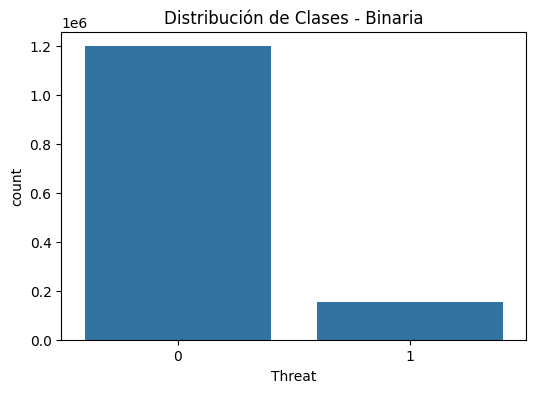

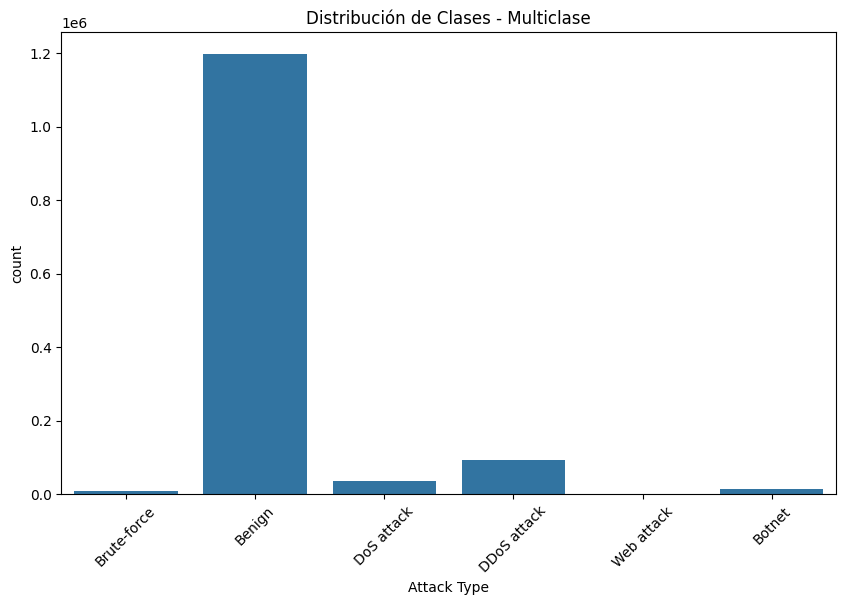

In [ ]:
# =======================
# 5. Visualización de la Distribución de Etiquetas
# =======================
print("\n[INFO] Visualizando la distribución de etiquetas...")

plt.figure(figsize=(6, 4))
sns.countplot(x='Threat', data=df_all)
plt.title('Distribución de Clases - Binaria')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x='Attack Type', data=df_all)
plt.title('Distribución de Clases - Multiclase')
plt.xticks(rotation=45)
plt.show()


In [ ]:

# =======================
# 6. Preparación de Datos para Entrenamiento
# =======================
print("\n[INFO] Preparando datos para entrenamiento (binario y multicategoría)...")

# a) Separar características y etiquetas (binario)
X_binary = df_all.drop(['Label', 'Threat', 'Attack Type'], axis=1)
y_binary = df_all['Threat']

# Convertir etiquetas a índices numéricos (solo si fuera necesario,
# pero ya tenemos 0/1 en 'Threat' XD)
binary_label_mapping = {0: 0, 1: 1}
y_binary_indices = y_binary.map(binary_label_mapping)

# b) Separar características y etiquetas (multiclase)
X_multi = df_all.drop(['Label', 'Threat', 'Attack Type'], axis=1)
y_multi = df_all['Attack Type']

# Crear un mapeo a índices numéricos
unique_multi_labels = y_multi.unique()
multi_label_mapping = {label: idx for idx, label in enumerate(unique_multi_labels)}
y_multi_indices = y_multi.map(multi_label_mapping)

print(f" - X_binary shape: {X_binary.shape}, y_binary_indices shape: {y_binary_indices.shape}")
print(f" - X_multi shape: {X_multi.shape}, y_multi_indices shape: {y_multi_indices.shape}")


# =======================
# 7. División en Conjuntos de Entrenamiento y Prueba (Antes de SMOTE)
# =======================
print("\n[INFO] Dividiendo datos en entrenamiento y prueba...")

# Binario
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary,
    y_binary_indices,
    test_size=0.2,
    random_state=42,
    stratify=y_binary_indices
)

# Multiclase
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi_indices,
    test_size=0.2,
    random_state=42,
    stratify=y_multi_indices
)

print(" - Conjuntos binarios:")
print(f"   X_train_bin: {X_train_bin.shape}, y_train_bin: {y_train_bin.shape}")
print(f"   X_test_bin: {X_test_bin.shape}, y_test_bin: {y_test_bin.shape}")

print(" - Conjuntos multicategoría:")
print(f"   X_train_multi: {X_train_multi.shape}, y_train_multi: {y_train_multi.shape}")
print(f"   X_test_multi: {X_test_multi.shape}, y_test_multi: {y_test_multi.shape}")

# # Asegurar que sean int
y_train_bin = y_train_bin.astype(int)
y_test_bin = y_test_bin.astype(int)


[INFO] Preparando datos para entrenamiento (binario y multicategoría)...
 - X_binary shape: (1352924, 35), y_binary_indices shape: (1352924,)
 - X_multi shape: (1352924, 35), y_multi_indices shape: (1352924,)

[INFO] Dividiendo datos en entrenamiento y prueba...
 - Conjuntos binarios:
   X_train_bin: (1082339, 35), y_train_bin: (1082339,)
   X_test_bin: (270585, 35), y_test_bin: (270585,)
 - Conjuntos multicategoría:
   X_train_multi: (1082339, 35), y_train_multi: (1082339,)
   X_test_multi: (270585, 35), y_test_multi: (270585,)


In [ ]:
# ESTO NO SE USO
def evaluate_saved_models(
    folder_path,
    X_test,
    y_test,
    average='binary',
    class_labels=None
):
    """
    Busca en 'folder_path' todos los archivos que terminan en '_cicids2018.pkl' o '_cicids2018.keras'.
    Los carga como modelos y evalúa sobre (X_test, y_test).
    Imprime Accuracy, F1, etc y como es 'binary' también muestra curva ROC.

    - folder_path: Ruta a la carpeta donde se encuentran los modelos.
    - X_test, y_test: Conjunto de prueba.
    - average='binary': Para classification_report (puede ser 'binary', 'micro', 'macro', etc.).
    - class_labels: Lista de nombres de clases, útil para la matriz de confusión y classification_report.
                    Por ejemplo: ['Benign', 'Malicious'] si es binario.
    """
    model_files = os.listdir(folder_path)
    if not model_files:
        print(f"[INFO] No se encontraron archivos en {folder_path}")
        return

    for filename in model_files:
        full_path = os.path.join(folder_path, filename)

        # Evaluar si el nombre termina con '_cicids2018.pkl' o '_cicids2018.keras'
        if filename.endswith('_cicids2018.pkl'):
            print(f"\n[INFO] Cargando modelo .pkl: {filename}")
            try:
                model = joblib.load(full_path)
            except Exception as e:
                print(f"  [ERROR] No se pudo cargar {filename}: {e}")
                continue

            # Predecir
            try:
                y_pred = model.predict(X_test)
            except Exception as e:
                print(f"  [ERROR] Problema al predecir con {filename}: {e}")
                continue

        elif filename.endswith('_cicids2018.keras'):
            print(f"\n[INFO] Cargando modelo .keras: {filename}")
            try:
                model = load_model(full_path)
            except Exception as e:
                print(f"  [ERROR] No se pudo cargar {filename}: {e}")
                continue

            # Para keras, a veces necesitamos 'predict_classes',
            # pero en TF>=2.6 se usa argmax (si es multiclase):
            try:
                probs = model.predict(X_test)
                if average == 'binary':
                    # Asumimos que la salida es (N,2) o (N,1)
                    if probs.shape[1] == 1:
                        # Salida (N,1)
                        y_pred = (probs > 0.5).astype(int)
                    else:
                        # Salida (N,2)
                        y_pred = np.argmax(probs, axis=1)
                else:
                    # Caso multiclase
                    y_pred = np.argmax(probs, axis=1)
            except Exception as e:
                print(f"  [ERROR] Problema al predecir con {filename}: {e}")
                continue

        else:
            # No coincide con el sufijo deseado
            continue

        # Ahora evaluamos
        print(f"[INFO] Evaluando modelo: {filename}")
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average=average if average != 'binary' else 'binary')
        print(f"  -> Accuracy: {acc*100:.2f}%")
        print(f"  -> F1 ({average}): {f1:.4f}\n")

        # Reporte de Clasificación
        if class_labels:
            print("  -> Classification Report:")
            print(classification_report(y_test, y_pred, target_names=class_labels))
        else:
            print("  -> Classification Report (sin nombres de clase):")
            print(classification_report(y_test, y_pred))

        # Matriz de Confusión
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_labels, yticklabels=class_labels
                      if class_labels else True)
        plt.title(f"{filename} - Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

        # Curva ROC (si es binario)
        if average == 'binary':
            # Necesitamos probabilidades predict_proba o model.predict
            try:
                if filename.endswith('_cicids2018.pkl'):
                    # scikit-learn model
                    y_scores = model.predict_proba(X_test)[:,1]
                else:
                    # keras model (arriba ya se calbulo 'probs')
                    if probs.shape[1] == 1:
                        # Salida (N,1)
                        y_scores = probs.ravel()
                    else:
                        # Salida (N,2)
                        y_scores = probs[:,1]

                fpr, tpr, thresholds = roc_curve(y_test, y_scores)
                roc_auc = auc(fpr, tpr)
                plt.figure()
                plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
                plt.plot([0, 1], [0, 1], 'k--')
                plt.title(f"{filename} - ROC Curve")
                plt.xlabel('False Positive Rate')
                plt.ylabel('True Positive Rate')
                plt.legend(loc="lower right")
                plt.show()

            except Exception as e:
                print(f"  [WARN] No se pudo generar curva ROC para {filename}: {e}")

    print("\n[INFO] Evaluación de modelos terminada.")



# uso:
# folder_path = "/content/drive/MyDrive/MisModelos"
# evaluate_saved_models(
#     folder_path=folder_path,
#     X_test=X_test_bin,
#     y_test=y_test_bin,
#     average='binary',
#     class_labels=['Benign','Malicious']
# )


### a) Clasificación Binaria

In [ ]:
pip show pandas

Name: pandasNote: you may need to restart the kernel to use updated packages.

Version: 2.2.2
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
All rights reserved.

Copyright (c) 2011-2023, Open source contributors.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

* Redistributions of source code must retain the above copyright notice, this
  list of conditions and the following disclaimer.

* Redistributions in binary form must reproduce the above copyright notice,
  this list of conditions and the following disclaimer in the documentation
  and/or other materials provided with the distribution.

* Neither the name of

In [ ]:
print("Evaluando modelos para Clasificación Binaria...")
binary_class_labels = ['Benign', 'Malicious']

Evaluando modelos para Clasificación Binaria...


#### Clasificación Binaria

##### XGBoost



In [ ]:
def objective(trial):
    """
    Función objetivo para Optuna.
    - Configuración de hiperparámetros
    - Validación cruzada
    - Pipeline con SMOTE + Escalado + XGBClassifier
    - Calcula el promedio del F1-score en la validación.
    """
    # Hiperparámetros
    n_estimators = trial.suggest_int('n_estimators', 50, 128)
    max_depth = trial.suggest_int('max_depth', 2, 6)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
    subsample = trial.suggest_categorical('subsample', [0.5, 0.8])
    colsample_bytree = trial.suggest_categorical('colsample_bytree', [0.5, 0.8])

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
        # probability=True
    )

    # Configuración del pipeline
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote', SMOTE(random_state=42)),
        ('scaler', MinMaxScaler()),
        ('model', model)
    ])

    # Validación cruzada
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []
    for train_idx, val_idx in cv.split(X_train_bin, y_train_bin):
        # cv.split(X_train_bin, y_train_bin), train_idx y val_idx
        # son índices de filas, mientras que X_train_bin[...] y
        # y_train_bin[...] (siendo pandas.DataFrame) interpretan esos valores
        # como nombres de columnas en vez de filas.
        # para eso usamos .iloc para seleccionar filas por posición entera en DataFrames
        # train_idx y val_idx se interpretan como posiciones de filas.
        # X_train_bin.iloc[train_idx] regresa correctamente las filas requeridas.

        X_train_fold = X_train_bin.iloc[train_idx]
        y_train_fold = y_train_bin.iloc[train_idx]
        X_val_fold   = X_train_bin.iloc[val_idx]
        y_val_fold   = y_train_bin.iloc[val_idx]

        pipeline.fit(X_train_fold, y_train_fold)
        y_pred_val = pipeline.predict(X_val_fold)
        f1 = f1_score(y_val_fold, y_pred_val)
        f1_scores.append(f1)

    return np.mean(f1_scores)


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)
best_score = study.best_value
best_params = study.best_trial.params

print("Best hyperparameters:", best_params)
print("Best mean CV F1-score:", best_score)

# Entrenamiento del modelo final
final_model = XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric="logloss"
    # probability=True
)
final_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=42)),
    ('scaler', MinMaxScaler()),
    ('model', final_model)
])

start_time = time.time()
final_pipeline.fit(X_train_bin, y_train_bin)
end_time = time.time()
print("Training time (final model):", end_time - start_time, "seconds")

start_time = time.time()
y_pred_test = final_pipeline.predict(X_test_bin)
end_time = time.time()
print("Testing time (final model):", end_time - start_time, "seconds")

f1_val = f1_score(y_test_bin, y_pred_test) * 100
acc_val = accuracy_score(y_test_bin, y_pred_test) * 100
print(f"F1 Score in test: {f1_val:.2f}%")
print(f"Accuracy Score in test: {acc_val:.2f}%")

CLF_train = final_pipeline.score(X_train_bin, y_train_bin)
CLF_test = final_pipeline.score(X_test_bin, y_test_bin)
print(f"Train Score: {CLF_train}")
print(f"Test Score: {CLF_test}")

# Guardar el pipeline entrenado
modelo_ruta = guardar_modelo(final_pipeline, "XGB_model_bin_cicids2018")

# Cargar el modelo guardado para pruebas futuras
loaded_model = cargar_modelo("XGB_model_bin_cicids2018")
print("Loaded model accuracy: ", loaded_model.score(X_test_bin, y_test_bin) * 100)


[I 2025-03-13 03:03:58,567] A new study created in memory with name: no-name-a718c807-895c-46a5-a7f6-eb607b6a7bf2
[I 2025-03-13 03:06:57,897] Trial 0 finished with value: 0.8462711918145187 and parameters: {'n_estimators': 87, 'max_depth': 2, 'learning_rate': 0.02644748184127963, 'subsample': 0.8, 'colsample_bytree': 0.5}. Best is trial 0 with value: 0.8462711918145187.
[I 2025-03-13 03:10:16,577] Trial 1 finished with value: 0.9867664980505908 and parameters: {'n_estimators': 115, 'max_depth': 4, 'learning_rate': 0.060818159573454454, 'subsample': 0.5, 'colsample_bytree': 0.8}. Best is trial 1 with value: 0.9867664980505908.
[I 2025-03-13 03:13:24,335] Trial 2 finished with value: 0.9487036697315373 and parameters: {'n_estimators': 110, 'max_depth': 3, 'learning_rate': 0.03926775929274755, 'subsample': 0.5, 'colsample_bytree': 0.8}. Best is trial 1 with value: 0.9867664980505908.
[I 2025-03-13 03:16:32,103] Trial 3 finished with value: 0.9362728957573635 and parameters: {'n_estimators

Best hyperparameters: {'n_estimators': 115, 'max_depth': 4, 'learning_rate': 0.060818159573454454, 'subsample': 0.5, 'colsample_bytree': 0.8}
Best mean CV F1-score: 0.9867664980505908
Training time (final model): 124.7850124835968 seconds
Testing time (final model): 1.3256497383117676 seconds
F1 Score in test: 99.23%
Accuracy Score in test: 99.82%
Train Score: 0.9982094334584636
Test Score: 0.9982075872646303
Modelo guardado en: /content/drive/MyDrive/Modelos/XGB_model_bin_cicids2018_cicids2018.pkl
Modelo XGB_model_bin_cicids2018 cargado correctamente desde /content/drive/MyDrive/Modelos/XGB_model_bin_cicids2018_cicids2018.pkl
Loaded model accuracy:  99.82075872646303


##### Gradient Boosting Machines (LightGBM)



In [ ]:
# =========================
# FUNCIÓN OBJETIVO PARA OPTUNA
# =========================
def objective_lightgbm_binary(trial):
    """
    Función objetivo usando validación cruzada (3-Fold).
    Se construye un pipeline con SimpleImputer, SMOTE, MinMaxScaler y LGBMClassifier.
    Se mide el F1-score promedio.
    """

    # Hiperparámetros propuestos por el trial de Optuna
    param = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
    }

    # Modelo LightGBM con probability=True
    # random_state para reproducibilidad
    model = lgb.LGBMClassifier(
        **param,
        random_state=42,
        probability=True
    )

    # Pipeline: Imputación, SMOTE, Escalado y Modelo
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote', SMOTE(random_state=42)),
        ('scaler', MinMaxScaler()),
        ('model', model)
    ])

    # Validación cruzada con 3 folds estratificados
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []

    for train_idx, val_idx in cv.split(X_train_bin, y_train_bin):
        X_train_fold = X_train_bin.iloc[train_idx]
        y_train_fold = y_train_bin.iloc[train_idx]
        X_val_fold   = X_train_bin.iloc[val_idx]
        y_val_fold   = y_train_bin.iloc[val_idx]

        pipeline.fit(X_train_fold, y_train_fold)
        y_pred_val = pipeline.predict(X_val_fold)
        f1_fold = f1_score(y_val_fold, y_pred_val)
        f1_scores.append(f1_fold)

    return np.mean(f1_scores)


# =========================
# ESTUDIO OPTUNA
# =========================
study = optuna.create_study(direction='maximize')
study.optimize(objective_lightgbm_binary, n_trials=10)

best_score = study.best_value
best_params = study.best_trial.params

print("Best hyperparameters:", best_params)
print("Best mean CV F1-score:", best_score)


# =========================
# ENTRENAR MODELO FINAL
# =========================
# Construimos un LGBMClassifier con los mejores parámetros
final_model = lgb.LGBMClassifier(
    **best_params,
    random_state=42,
    # probability=True
)

# Pipeline final (uso de todo X_train_bin, y_train_bin)
final_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=42)),
    ('scaler', MinMaxScaler()),
    ('model', final_model)
])

# Tiempo de entrenamiento
start_time = time.time()
final_pipeline.fit(X_train_bin, y_train_bin)
train_time = time.time() - start_time
print(f"Training time (final model): {train_time:.4f} seconds")

# Tiempo de predicción
start_time = time.time()
y_pred_test = final_pipeline.predict(X_test_bin)
pred_time = time.time() - start_time
print(f"Testing time (final model): {pred_time:.4f} seconds")

# Métricas
f1_val = f1_score(y_test_bin, y_pred_test) * 100
acc_val = accuracy_score(y_test_bin, y_pred_test) * 100
print(f"F1 Score in test: {f1_val:.2f}%")
print(f"Accuracy Score in test: {acc_val:.2f}%")

# Score en entrenamiento y prueba
CLF_train = final_pipeline.score(X_train_bin, y_train_bin)
CLF_test = final_pipeline.score(X_test_bin, y_test_bin)
print(f"Train Score: {CLF_train}")
print(f"Test Score: {CLF_test}")

# =========================
# GUARDAR Y CARGAR PIPELINE
# =========================
modelo_ruta = guardar_modelo(final_pipeline, "LightGBM_bin_cicids2018")
loaded_model = cargar_modelo("LightGBM_bin_cicids2018")
print(f"Precisión del modelo cargado: {loaded_model.score(X_test_bin, y_test_bin)}")


[I 2025-03-13 04:06:18,113] A new study created in memory with name: no-name-00b1dca5-689c-44ab-b182-101cc2797b85


[LightGBM] [Warning] Unknown parameter: probability
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] feature_fraction is set=0.7279541591278418, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7279541591278418
[LightGBM] [Warning] bagging_fraction is set=0.5648434069937918, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5648434069937918
[LightGBM] [Warning] Unknown parameter: probability
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] feature_fraction is set=0.7279541591278418, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7279541591278418
[LightGBM] [Warning] bagging_fraction is set=0.5648434069937918, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5648434069937918
[LightGBM] [Info] Number of positive: 638680, number of negative: 638680
[Ligh

[I 2025-03-13 04:10:11,108] Trial 0 finished with value: 0.9984569257746948 and parameters: {'learning_rate': 0.01661587523220478, 'num_leaves': 86, 'feature_fraction': 0.7279541591278418, 'bagging_fraction': 0.5648434069937918, 'bagging_freq': 6, 'min_child_samples': 77}. Best is trial 0 with value: 0.9984569257746948.


[LightGBM] [Warning] Unknown parameter: probability
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.7077354696744249, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7077354696744249
[LightGBM] [Warning] bagging_fraction is set=0.9411174004236642, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9411174004236642
[LightGBM] [Warning] Unknown parameter: probability
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] feature_fraction is set=0.7077354696744249, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7077354696744249
[LightGBM] [Warning] bagging_fraction is set=0.9411174004236642, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9411174004236642
[LightGBM] [Info] Number of positive: 638680, number of negative: 638680
[Ligh

[I 2025-03-13 04:14:28,140] Trial 1 finished with value: 0.9996501030759694 and parameters: {'learning_rate': 0.04540523845899091, 'num_leaves': 130, 'feature_fraction': 0.7077354696744249, 'bagging_fraction': 0.9411174004236642, 'bagging_freq': 2, 'min_child_samples': 19}. Best is trial 1 with value: 0.9996501030759694.


...

[LightGBM] [Warning] Unknown parameter: probability
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.7834177794933899, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7834177794933899
[LightGBM] [Warning] bagging_fraction is set=0.5527677235917892, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5527677235917892
[LightGBM] [Warning] Unknown parameter: probability
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.7834177794933899, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7834177794933899
[LightGBM] [Warning] bagging_fraction is set=0.5527677235917892, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5527677235917892
[LightGBM] [Info] Number of positive: 638680, number of negative: 638680
[Ligh

[I 2025-03-13 04:41:19,381] Trial 8 finished with value: 0.9993566499462928 and parameters: {'learning_rate': 0.013635512265235619, 'num_leaves': 158, 'feature_fraction': 0.7834177794933899, 'bagging_fraction': 0.5527677235917892, 'bagging_freq': 3, 'min_child_samples': 11}. Best is trial 5 with value: 0.9997667369365372.


[LightGBM] [Warning] Unknown parameter: probability
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.5509932825388268, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5509932825388268
[LightGBM] [Warning] bagging_fraction is set=0.7386296050585123, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7386296050585123
[LightGBM] [Warning] Unknown parameter: probability
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.5509932825388268, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5509932825388268
[LightGBM] [Warning] bagging_fraction is set=0.7386296050585123, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7386296050585123
[LightGBM] [Info] Number of positive: 638680, number of negative: 638680
[Ligh

[I 2025-03-13 04:45:01,939] Trial 9 finished with value: 0.9995737031441752 and parameters: {'learning_rate': 0.04841044516458569, 'num_leaves': 111, 'feature_fraction': 0.5509932825388268, 'bagging_fraction': 0.7386296050585123, 'bagging_freq': 1, 'min_child_samples': 60}. Best is trial 5 with value: 0.9997667369365372.


Best hyperparameters: {'learning_rate': 0.13655856128510088, 'num_leaves': 32, 'feature_fraction': 0.8450178757972995, 'bagging_fraction': 0.5222276663053877, 'bagging_freq': 4, 'min_child_samples': 59}
Best mean CV F1-score: 0.9997667369365372
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] feature_fraction is set=0.8450178757972995, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8450178757972995
[LightGBM] [Warning] bagging_fraction is set=0.5222276663053877, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5222276663053877
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] feature_fraction is set=0.8450178757972995, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8450178757972995
[LightGBM] [Warning] bagging_fraction is set=0.5222276663053877, subsample=1.0 will 

##### GNB

In [ ]:
# =============================================================================
# 1) Configuración de DEAP para el algoritmo genético
# =============================================================================
# Creación de clases fitness e individuos (si no existen)
if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Definimos el rango de var_smoothing para GaussianNB
toolbox.register("var_smoothing", np.random.uniform, 1e-10, 1e-1)

# Definimos "individual" como una lista con un solo gen [var_smoothing]
toolbox.register("individual", lambda: creator.Individual([toolbox.var_smoothing()]))

# Definimos "population" para generar la población de individuos
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# =============================================================================
# 2) Definir función de evaluación (usa Pipeline + CV estratificado)
# =============================================================================
def evaluate(individual):
    """
    Evalúa un individuo que contiene [var_smoothing].
    Retorna la media de accuracy en validación cruzada (3 folds).
    """
    # Tomamos var_smoothing del individuo (asegurando que no sea menor a 1e-10)
    var_smoothing = max(1e-10, individual[0])

    # Crear modelo GaussianNB con ese var_smoothing
    model = GaussianNB(var_smoothing=var_smoothing)

    # Crear pipeline con preprocesamiento y modelo
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote', SMOTE(random_state=42)),
        ('scaler', MinMaxScaler()),
        ('model', model)
    ])

    # Validación cruzada estratificada (3 folds)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_train_bin, y_train_bin):
        X_train_fold = X_train_bin.iloc[train_idx]
        y_train_fold = y_train_bin.iloc[train_idx]
        X_val_fold   = X_train_bin.iloc[val_idx]
        y_val_fold   = y_train_bin.iloc[val_idx]

        pipeline.fit(X_train_fold, y_train_fold)
        y_pred_val = pipeline.predict(X_val_fold)
        score = accuracy_score(y_val_fold, y_pred_val)
        scores.append(score)

    return (np.mean(scores),)

toolbox.register("evaluate", evaluate)

# Operadores genéticos: cruce, mutación y selección
toolbox.register("mate", tools.cxBlend, alpha=0.5)  # Cruce (Blend)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1e-2, indpb=0.2)  # Mutación gaussiana
toolbox.register("select", tools.selTournament, tournsize=3)

# =============================================================================
# 3) Función objetivo para Optuna, usando la misma lógica
#    (Pero solo con var_smoothing para GNB)
# =============================================================================
def objective(trial):
    var_smoothing = trial.suggest_loguniform('var_smoothing', 1e-10, 1e-1)
    individual = [var_smoothing]
    # Retornamos la media de accuracy en validación cruzada
    return evaluate(individual)[0]

# =============================================================================
# 4) Ejecución del algoritmo genético
#    - Cada generación hace un varAnd + evaluate.
#    - Luego, se ejecuta un pequeño estudio de Optuna (5 trials) y se actualiza
#      el mejor var_smoothing en la población.
# =============================================================================
# Definir variables necesarias para el proceso evolutivo
population_size = 10       # Tamaño de la población
num_generations = 10       # Número de generaciones
cxpb, mutpb = 0.5, 0.2      # Probabilidades de cruce y mutación

# Crear la población inicial
population = toolbox.population(n=population_size)

print("=== Iniciando proceso evolutivo ===")
for gen in range(num_generations):
    print(f"\n--- Generación {gen} ---")

    # Generar descendencia mediante cruce y mutación
    offspring = algorithms.varAnd(population, toolbox, cxpb, mutpb)
    for ind in offspring:
        ind[0] = max(1e-10, ind[0])

    # Evaluar a cada hijo y asignar fitness
    fits = toolbox.map(toolbox.evaluate, offspring)
    for fit, ind in zip(fits, offspring):
        ind.fitness.values = fit

    # Seleccionar la nueva población mediante torneo
    population = toolbox.select(offspring, len(population))

    # Cada generación: ejecutar un pequeño estudio de Optuna (5 trials)
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=5)

    # Actualizar el mejor var_smoothing en la población
    best_individual = tools.selBest(population, k=1)[0]
    best_params = study.best_trial.params
    best_individual[0] = best_params['var_smoothing']

# Extraer el mejor var_smoothing final de la población
best_var_smoothing = tools.selBest(population, k=1)[0][0]
print(f"\n=== Evolución terminada. best_var_smoothing = {best_var_smoothing} ===")

# =============================================================================
# 5) Entrenar modelo final con best_var_smoothing
# =============================================================================
final_model = GaussianNB(var_smoothing=best_var_smoothing)
final_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=42)),
    ('scaler', MinMaxScaler()),
    ('model', final_model)
])

# Medir el tiempo de entrenamiento final
start_time = time.time()
final_pipeline.fit(X_train_bin, y_train_bin)
train_time = time.time() - start_time
print(f"Training time (final model): {train_time:.4f} seconds")

# Medir el tiempo de predicción final
start_time = time.time()
y_pred_test = final_pipeline.predict(X_test_bin)
test_time = time.time() - start_time
print(f"Testing time (final model): {test_time:.4f} seconds")

# Calcular métricas en el set de prueba
f1_val = f1_score(y_test_bin, y_pred_test) * 100
acc_val = accuracy_score(y_test_bin, y_pred_test) * 100
print(f"F1 Score in test: {f1_val:.2f}%")
print(f"Accuracy Score in test: {acc_val:.2f}%")
CLF_train = final_pipeline.score(X_train_bin, y_train_bin)
CLF_test = final_pipeline.score(X_test_bin, y_test_bin)
print(f"Train Score: {CLF_train}")
print(f"Test Score: {CLF_test}")
print(f"\nBest var_smoothing final: {best_var_smoothing}")

# =============================================================================
# 6) Guardar y cargar el modelo final
# =============================================================================
modelo_ruta = guardar_modelo(final_pipeline, "final_gnb_bin_cicids2018")
loaded_gnb = cargar_modelo("final_gnb_bin_cicids2018")
print(f"Precisión del modelo cargado: {loaded_gnb.score(X_test_bin, y_test_bin)}")


=== Iniciando proceso evolutivo ===

--- Generación 0 ---


[I 2025-03-18 15:40:13,999] A new study created in memory with name: no-name-7628e0b3-d663-4ee7-87d4-b1d2c05b387b
[I 2025-03-18 15:44:04,043] Trial 0 finished with value: 0.8296845969740699 and parameters: {'var_smoothing': 2.3094031112584904e-08}. Best is trial 0 with value: 0.8296845969740699.
[I 2025-03-18 15:47:40,263] Trial 1 finished with value: 0.8321995202585718 and parameters: {'var_smoothing': 6.33728919922734e-07}. Best is trial 1 with value: 0.8321995202585718.
[I 2025-03-18 15:51:19,876] Trial 2 finished with value: 0.8059674421514639 and parameters: {'var_smoothing': 0.010069761190468074}. Best is trial 1 with value: 0.8321995202585718.
[I 2025-03-18 15:54:58,655] Trial 3 finished with value: 0.8335502965335059 and parameters: {'var_smoothing': 0.00042399934839370515}. Best is trial 3 with value: 0.8335502965335059.
[I 2025-03-18 15:58:34,078] Trial 4 finished with value: 0.8297492723134307 and parameters: {'var_smoothing': 6.2215392212901936e-09}. Best is trial 3 with va


--- Generación 1 ---


[I 2025-03-18 16:34:28,117] A new study created in memory with name: no-name-f3dd58b8-a5f5-4181-b159-8485a12749d4
[I 2025-03-18 16:38:02,540] Trial 0 finished with value: 0.832744634214497 and parameters: {'var_smoothing': 0.0012732292181305681}. Best is trial 0 with value: 0.832744634214497.
[I 2025-03-18 16:41:36,899] Trial 1 finished with value: 0.8038645891982256 and parameters: {'var_smoothing': 0.01812347639493092}. Best is trial 0 with value: 0.832744634214497.
[I 2025-03-18 16:45:10,635] Trial 2 finished with value: 0.834330090250758 and parameters: {'var_smoothing': 4.894109571232959e-05}. Best is trial 2 with value: 0.834330090250758.
[I 2025-03-18 16:48:42,929] Trial 3 finished with value: 0.829313180544827 and parameters: {'var_smoothing': 2.916836264180185e-10}. Best is trial 2 with value: 0.834330090250758.
[I 2025-03-18 16:52:16,301] Trial 4 finished with value: 0.8255860698447984 and parameters: {'var_smoothing': 0.0015708196598252263}. Best is trial 2 with value: 0.834


--- Generación 2 ---


...


--- Generación 8 ---


[I 2025-03-18 22:51:37,101] A new study created in memory with name: no-name-2db37bdd-1e5e-4d71-a190-c364ea870505
[I 2025-03-18 22:55:12,998] Trial 0 finished with value: 0.8304098776257574 and parameters: {'var_smoothing': 1.6422742910619906e-07}. Best is trial 0 with value: 0.8304098776257574.
[I 2025-03-18 22:58:46,147] Trial 1 finished with value: 0.8021350016568959 and parameters: {'var_smoothing': 0.02600100019817987}. Best is trial 0 with value: 0.8304098776257574.
[I 2025-03-18 23:02:20,497] Trial 2 finished with value: 0.8350590674259822 and parameters: {'var_smoothing': 2.2252504356700975e-05}. Best is trial 2 with value: 0.8350590674259822.
[I 2025-03-18 23:06:01,427] Trial 3 finished with value: 0.8339050842190763 and parameters: {'var_smoothing': 0.00013603218969234144}. Best is trial 2 with value: 0.8350590674259822.
[I 2025-03-18 23:09:40,227] Trial 4 finished with value: 0.8297520439499735 and parameters: {'var_smoothing': 7.526365922441819e-09}. Best is trial 2 with va


--- Generación 9 ---


[I 2025-03-18 23:45:37,723] A new study created in memory with name: no-name-20fa94f0-e009-4a7e-b7a5-a51ca6a5cc66
[I 2025-03-18 23:49:10,811] Trial 0 finished with value: 0.8297187820245643 and parameters: {'var_smoothing': 3.797167045776018e-08}. Best is trial 0 with value: 0.8297187820245643.
[I 2025-03-18 23:52:45,443] Trial 1 finished with value: 0.8340057935557446 and parameters: {'var_smoothing': 2.1344484224338748e-06}. Best is trial 1 with value: 0.8340057935557446.
[I 2025-03-18 23:56:35,426] Trial 2 finished with value: 0.8353057559007833 and parameters: {'var_smoothing': 6.998370812530312e-06}. Best is trial 2 with value: 0.8353057559007833.
[I 2025-03-19 00:00:21,961] Trial 3 finished with value: 0.8303655292412482 and parameters: {'var_smoothing': 1.5718620086790188e-07}. Best is trial 2 with value: 0.8353057559007833.
[I 2025-03-19 00:04:09,624] Trial 4 finished with value: 0.829695684111812 and parameters: {'var_smoothing': 1.9868239095160115e-08}. Best is trial 2 with v


=== Evolución terminada. best_var_smoothing = 6.998370812530312e-06 ===
Training time (final model): 154.5306 seconds
Testing time (final model): 1.6840 seconds
F1 Score in test: 57.16%
Accuracy Score in test: 83.09%
Train Score: 0.8322965355586374
Test Score: 0.8309145000646747

Best var_smoothing final: 6.998370812530312e-06
Modelo guardado en: /content/drive/MyDrive/Modelos/final_gnb_bin_cicids2018_cicids2018.pkl
Modelo final_gnb_bin_cicids2018 cargado correctamente desde /content/drive/MyDrive/Modelos/final_gnb_bin_cicids2018_cicids2018.pkl
Precisión del modelo cargado: 0.8309145000646747


##### Logistic Regression

In [ ]:
# ============================================================================
# FUNCIÓN OBJETIVO (Regresión Logística, clasificación binaria)
# ============================================================================
def objective_logistic_regression_binary(trial):
    """
    Función objetivo para optimizar con Optuna.
    Entrena un pipeline que incluye:
      - SimpleImputer (strategy='median')
      - SMOTE
      - MinMaxScaler
      - LogisticRegression (hiperparámetros: C y solver)
    Retorna la exactitud (accuracy) en el set de prueba (X_test_bin, y_test_bin).
    """
    # Sugerir hiperparámetros
    C = trial.suggest_float('C', 0.01, 100.0, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear'])

    # Configurar el modelo de regresión logística
    model = LogisticRegression(
        C=C,
        solver=solver,
        random_state=42
    )

    # Configuración del pipeline
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote', SMOTE(random_state=42)),
        ('scaler', MinMaxScaler()),
        ('logreg', model)
    ])

    # Entrenar el pipeline en el set de entrenamiento binario
    pipeline.fit(X_train_bin, y_train_bin)

    # Predecir en el set de prueba binario
    y_pred = pipeline.predict(X_test_bin)

    # Retornar la exactitud (accuracy)
    return accuracy_score(y_test_bin, y_pred)

# ============================================================================
# CREAR Y EJECUTAR EL ESTUDIO DE OPTUNA
# ============================================================================
study = optuna.create_study(direction='maximize')
study.optimize(objective_logistic_regression_binary, n_trials=100)

# Extraer los mejores hiperparámetros y la métrica obtenida
best_params = study.best_trial.params
best_score = study.best_trial.value

print("Mejores hiperparámetros:", best_params)
print("Mejor accuracy alcanzada (Test):", best_score)

# ============================================================================
# ENTRENAMIENTO FINAL CON LOS MEJORES HIPERPARÁMETROS
# ============================================================================
best_logreg = LogisticRegression(
    **best_params,
    random_state=42
)

# Configurar el pipeline final usando todo X_train_bin, y_train_bin
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=42)),
    ('scaler', MinMaxScaler()),
    ('logreg', best_logreg)
])

# Medir tiempo de entrenamiento
start_time = time.time()
pipeline.fit(X_train_bin, y_train_bin)
end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo de entrenamiento: {training_time:.4f} segundos")

# Medir tiempo de predicción
start_time = time.time()
y_pred = pipeline.predict(X_test_bin)
end_time = time.time()
prediction_time = end_time - start_time
print(f"Tiempo de predicción: {prediction_time:.4f} segundos")

# Calcular métricas en el set de prueba
accuracy_val = accuracy_score(y_test_bin, y_pred)
f1_val = f1_score(y_test_bin, y_pred)
print(f"Accuracy en test: {accuracy_val * 100:.2f}%")
print(f"F1-Score en test: {f1_val * 100:.2f}%")

# Mostrar score en entrenamiento y prueba
train_score = pipeline.score(X_train_bin, y_train_bin)
test_score = pipeline.score(X_test_bin, y_test_bin)
print(f"Train Score: {train_score}")
print(f"Test Score: {test_score}")

print("Mejores hiperparámetros:", best_params)
print("Mejor score:", best_score)

# ============================================================================
# GUARDAR Y CARGAR EL PIPELINE ENTRENADO
# ============================================================================
modelo_ruta = guardar_modelo(pipeline, "LogReg_bin_cicids2018")
loaded_model = cargar_modelo("LogReg_bin_cicids2018")
loaded_accuracy = accuracy_score(y_test_bin, loaded_model.predict(X_test_bin))
print(f"Precisión del modelo cargado: {loaded_accuracy * 100:.2f}%")


[I 2025-03-20 02:08:56,364] A new study created in memory with name: no-name-d82bedb8-bde9-4a1e-b39d-ae14dc84158b
[I 2025-03-20 02:11:56,245] Trial 0 finished with value: 0.9144889775856015 and parameters: {'C': 0.0265894890739723, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.9144889775856015.
[I 2025-03-20 02:15:03,233] Trial 1 finished with value: 0.9207420958294067 and parameters: {'C': 0.5271719808644868, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.9207420958294067.
[I 2025-03-20 02:18:10,926] Trial 2 finished with value: 0.920542528225881 and parameters: {'C': 0.33763023585296076, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.9207420958294067.
[I 2025-03-20 02:21:07,873] Trial 3 finished with value: 0.9182881534453129 and parameters: {'C': 0.12569399312729362, 'solver': 'liblinear'}. Best is trial 1 with value: 0.9207420958294067.
[I 2025-03-20 02:24:22,388] Trial 4 finished with value: 0.9216438457416338 and parameters: {'C': 29.274956806603115, 'solver': 'lbfgs'}.

Mejores hiperparámetros: {'C': 98.25795682317144, 'solver': 'liblinear'}
Mejor accuracy alcanzada (Test): 0.9491620008500101
Tiempo de entrenamiento: 525.8137 segundos
Tiempo de predicción: 1.1684 segundos
Accuracy en test: 94.92%
F1-Score en test: 81.79%
Train Score: 0.9490002670143088
Test Score: 0.9491620008500101
Mejores hiperparámetros: {'C': 98.25795682317144, 'solver': 'liblinear'}
Mejor score: 0.9491620008500101
Modelo guardado en: /content/drive/MyDrive/Modelos/LogReg_bin_cicids2018_cicids2018.pkl
Modelo LogReg_bin_cicids2018 cargado correctamente desde /content/drive/MyDrive/Modelos/LogReg_bin_cicids2018_cicids2018.pkl
Precisión del modelo cargado: 94.92%


##### Decision Tree

In [ ]:
# ============================================================================
# Función objetivo (Decision Tree, binario)
# ============================================================================
def objective_decision_tree_binary(trial):
    """
    Esta función crea y entrena un pipeline que incluye:
      - SimpleImputer (estrategia: 'median')
      - SMOTE (para balancear clases)
      - MinMaxScaler (escalado de características a [0,1])
      - DecisionTreeClassifier, cuyas hiperparámetros se optimizan con Optuna.

    Se optimizan:
      - max_depth: profundidad máxima (entre 3 y 30)
      - min_samples_split: número mínimo de muestras para dividir un nodo (entre 2 y 10)
      - max_features: número máximo de características a considerar (entre 1 y el total de features en X_train_bin)

    La función retorna la exactitud (accuracy) en el conjunto de prueba.
    """
    # Sugerir hiperparámetros según el rango definido
    max_depth = trial.suggest_int('max_depth', 3, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    max_features = trial.suggest_int('max_features', 1, X_train_bin.shape[1])

    # Crear el modelo DecisionTreeClassifier con los hiperparámetros sugeridos
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42
    )

    # Construir el pipeline
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote', SMOTE(random_state=42)),
        ('scaler', MinMaxScaler()),
        ('model', model)
    ])

    # Entrenar el pipeline en el conjunto de entrenamiento binario
    pipeline.fit(X_train_bin, y_train_bin)

    # Predecir en el conjunto de prueba y calcular la accuracy
    y_pred = pipeline.predict(X_test_bin)

    # Calcular y retornar F1-score
    return f1_score(y_test_bin, y_pred)

# ============================================================================
# Crear y ejecutar el estudio de Optuna
# ============================================================================
study = optuna.create_study(direction='maximize')
study.optimize(objective_decision_tree_binary, n_trials=100)

# Extraer los mejores hiperparámetros y la mejor puntuación
best_params = study.best_trial.params
best_score = study.best_trial.value

print(f"Best Hyperparameters: {best_params}")
print(f"Best F1-Score (Score) (test): {best_score:.4f}")

# ============================================================================
# Configurar el modelo final con los mejores hiperparámetros
# ============================================================================
best_dt = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    max_features=best_params['max_features'],
    random_state=42
)

# Construir el pipeline final con todo el conjunto de entrenamiento binario
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=42)),
    ('scaler', MinMaxScaler()),
    ('model', best_dt)
])

# ============================================================================
# Entrenamiento final: Medir tiempo de entrenamiento
# ============================================================================
start_time = time.time()
pipeline.fit(X_train_bin, y_train_bin)
end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time:.4f} seconds")

# ============================================================================
# Predicción: Medir tiempo de predicción en el conjunto de prueba
# ============================================================================
start_time = time.time()
y_pred = pipeline.predict(X_test_bin)
end_time = time.time()
prediction_time = end_time - start_time
print(f"Prediction time: {prediction_time:.4f} seconds")

# ============================================================================
# Cálculo de métricas finales
# ============================================================================
accuracy_val = accuracy_score(y_test_bin, y_pred)
f1_val = f1_score(y_test_bin, y_pred)
train_score = pipeline.score(X_train_bin, y_train_bin) * 100
test_score = pipeline.score(X_test_bin, y_test_bin) * 100

print(f"Accuracy Score (test): {accuracy_val * 100:.2f}%")
print(f"F1 Score (test): {f1_val * 100:.2f}%")
print(f"Train Score: {train_score:.2f}%")
print(f"Test Score: {test_score:.2f}%")

# ============================================================================
# Guardar y cargar el pipeline entrenado
# ============================================================================
modelo_ruta = guardar_modelo(pipeline, "DecisionTree_bin_cicids2018")
loaded_model = cargar_modelo("DecisionTree_bin_cicids2018")
print("Loaded model accuracy:", loaded_model.score(X_test_bin, y_test_bin) * 100)


[I 2025-03-15 14:39:24,913] A new study created in memory with name: no-name-a83e0d59-0a4f-4389-a0f3-487a7efa9430
[I 2025-03-15 14:42:48,391] Trial 0 finished with value: 0.9953249441025925 and parameters: {'max_depth': 12, 'min_samples_split': 9, 'max_features': 35}. Best is trial 0 with value: 0.9953249441025925.
[I 2025-03-15 14:45:31,529] Trial 1 finished with value: 0.995812776022322 and parameters: {'max_depth': 12, 'min_samples_split': 8, 'max_features': 8}. Best is trial 1 with value: 0.995812776022322.
[I 2025-03-15 14:48:33,615] Trial 2 finished with value: 0.9989947705896484 and parameters: {'max_depth': 23, 'min_samples_split': 7, 'max_features': 12}. Best is trial 2 with value: 0.9989947705896484.
[I 2025-03-15 14:51:27,077] Trial 3 finished with value: 0.9992165123713436 and parameters: {'max_depth': 19, 'min_samples_split': 7, 'max_features': 11}. Best is trial 3 with value: 0.9992165123713436.
[I 2025-03-15 14:54:07,702] Trial 4 finished with value: 0.9889794334497478 a

Best Hyperparameters: {'max_depth': 29, 'min_samples_split': 7, 'max_features': 21}
Best Score: 0.9999002161982371
Training time: 195.4436 seconds
Prediction time: 1.7330 seconds
Accuracy Score (test): 99.99%
Train Score: 100.00%
Test Score: 99.99%
Modelo guardado en: /content/drive/MyDrive/Modelos/DecisionTree_bin_cicids2018_cicids2018.pkl
Modelo DecisionTree_bin_cicids2018 cargado correctamente desde /content/drive/MyDrive/Modelos/DecisionTree_bin_cicids2018_cicids2018.pkl
Loaded model accuracy: 99.99002161982371


##### Gradient Boosting Machines (CatBoost)

In [ ]:
# =============================================================================
# RUTAS DE ARCHIVO PARA CHECKPOINT, PARÁMETROS Y TIEMPO DE ENTRENAMIENTO
# =============================================================================
CHECKPOINT_PATH = '/content/drive/MyDrive/Modelos/optuna_catboost_study_bin.pkl'
BEST_PARAMS_PATH = '/content/drive/MyDrive/Modelos/best_hyperparameters_catboost_bin.json'
TRAIN_TIME_PATH = '/content/drive/MyDrive/Modelos/knn_train_time_bin.txt'

# =============================================================================
# Función objetivo para Optuna (CatBoost + Pipeline)
# =============================================================================
def objective_catboost(trial):
    """
    Función objetivo para optimizar un CatBoostClassifier en un pipeline.
    Se utiliza un pipeline que incluye:
      - SimpleImputer (estrategia: 'median')
      - SMOTE (para balancear las clases)
      - MinMaxScaler (para escalar las características a [0,1])
      - CatBoostClassifier, con hiperparámetros sugeridos por Optuna

    La función entrena el pipeline sobre el conjunto de entrenamiento binario
    y retorna la accuracy en el conjunto de prueba para que Optuna la maximice.
    """
    # Sugerir los hiperparámetros de CatBoost
    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255)
    }

    # Instanciar el modelo CatBoost con verbose=0 para no imprimir durante la optimización
    model = CatBoostClassifier(**param, verbose=0, random_state=42)

    # Construir el pipeline con preprocesamiento y el modelo
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote', SMOTE(random_state=42)),
        ('scaler', MinMaxScaler()),
        ('model', model)
    ])

    # Medir tiempo de entrenamiento
    start_time = time.time()
    pipeline.fit(X_train_bin, y_train_bin)
    train_time = time.time() - start_time

    # Medir tiempo de predicción
    start_time = time.time()
    preds = pipeline.predict(X_test_bin)
    pred_time = time.time() - start_time

    accuracy_val = accuracy_score(y_test_bin, preds)
    print(f"Training time: {train_time:.4f} seconds")
    print(f"Prediction time: {pred_time:.4f} seconds")

    return accuracy_val

# =============================================================================
# Cargar o crear el estudio de Optuna (checkpoint)
# =============================================================================
try:
    study_catboost = joblib.load(CHECKPOINT_PATH)
    print(f"Checkpoint loaded. Trials completed: {len(study_catboost.trials)}")
except FileNotFoundError:
    study_catboost = optuna.create_study(direction="maximize")
    print("No checkpoint found. Creating a new study.")

desired_trials = 100
completed_trials = len(study_catboost.trials)
remaining_trials = max(0, desired_trials - completed_trials)
if remaining_trials > 0:
    study_catboost.optimize(
        objective_catboost,
        n_trials=remaining_trials,
        callbacks=[lambda study, trial: joblib.dump(study, CHECKPOINT_PATH)]
    )
else:
    print("Desired number of trials already completed.")

# =============================================================================
# Guardar los mejores hiperparámetros obtenidos
# =============================================================================
best_params_catboost = study_catboost.best_trial.params
with open(BEST_PARAMS_PATH, 'w') as f:
    json.dump(best_params_catboost, f)
print(f"Best Hyperparameters for CatBoost: {best_params_catboost}")
print(f"Best mean CV accuracy: {study_catboost.best_trial.value}")

# =============================================================================
# Entrenamiento final con los mejores hiperparámetros
# =============================================================================
final_catboost = CatBoostClassifier(**best_params_catboost, verbose=0, random_state=42)
pipeline_final = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=42)),
    ('scaler', MinMaxScaler()),
    ('model', final_catboost)
])
start_time = time.time()
pipeline_final.fit(X_train_bin, y_train_bin)
final_train_time = time.time() - start_time
print(f"Final Training time: {final_train_time:.2f} seconds")

# Guardar el tiempo de entrenamiento en TRAIN_TIME_PATH
with open(TRAIN_TIME_PATH, 'w') as f:
    f.write(str(final_train_time))

start_time = time.time()
final_preds_bin = pipeline_final.predict(X_test_bin)
final_pred_time = time.time() - start_time
print(f"Final Prediction time: {final_pred_time:.2f} seconds")
final_accuracy = accuracy_score(y_test_bin, final_preds_bin) * 100
print(f"Final Test Accuracy for CatBoost: {final_accuracy:.2f}%")

# =============================================================================
# Guardar y cargar el pipeline final entrenado
# =============================================================================
modelo_ruta_catboost = guardar_modelo(pipeline_final, "catboost_bin_2018")
loaded_catboost = cargar_modelo("catboost_bin_2018")
loaded_accuracy = accuracy_score(y_test_bin, loaded_catboost.predict(X_test_bin)) * 100
print(f"Loaded model accuracy: {loaded_accuracy:.2f}%")


Checkpoint loaded. Trials completed: 100
Desired number of trials already completed.
Best Hyperparameters for CatBoost: {'iterations': 579, 'depth': 10, 'learning_rate': 0.05954961760062524, 'l2_leaf_reg': 0.01625569605772731, 'border_count': 191}
Best mean CV accuracy: 0.9999593473400226
Final Training time: 1021.01 seconds
Final Prediction time: 2.63 seconds
Final Test Accuracy for CatBoost: 100.00%
Modelo guardado en: /content/drive/MyDrive/Modelos/catboost_bin_2018_cicids2018.pkl
Modelo catboost_bin_2018 cargado correctamente desde /content/drive/MyDrive/Modelos/catboost_bin_2018_cicids2018.pkl
Loaded model accuracy: 100.00%


##### Redes Neuronales

In [ ]:
print("===================X_train_bin dtypes:===================")
print(X_train_bin.dtypes)

print("===================y_train_bin dtypes:===================")
print(y_train_bin.dtypes)

print("===================X_test_bin dtypes:===================")
print(X_test_bin.dtypes)

print("===================y_test_bin dtypes:===================")
print(y_test_bin.dtypes)

print("Tipo de X_train_bin:", type(X_train_bin))
print("Tipo de y_train_bin:", type(y_train_bin))
print("Tipo de X_test_bin:", type(X_test_bin))
print("Tipo de y_test_bin:", type(y_test_bin))


===================X_train_bin dtypes:===================
Dst Port              uint32
Protocol              object
Flow Duration          int64
Tot Fwd Pkts          uint32
Tot Bwd Pkts          uint32
Fwd Pkt Len Max      float32
Fwd Pkt Len Min      float32
Fwd Pkt Len Mean     float32
Bwd Pkt Len Max      float32
Bwd Pkt Len Min      float32
Bwd Pkt Len Mean     float32
Flow Byts/s          float32
Flow Pkts/s          float32
Flow IAT Mean        float32
Bwd IAT Tot          float64
Bwd IAT Mean         float32
Bwd IAT Std          float32
Bwd IAT Max          float64
Bwd IAT Min          float64
Fwd PSH Flags          uint8
Fwd URG Flags          uint8
Bwd Pkts/s           float32
Pkt Len Var          float32
FIN Flag Cnt           uint8
RST Flag Cnt           uint8
PSH Flag Cnt           uint8
ACK Flag Cnt           uint8
URG Flag Cnt           uint8
Down/Up Ratio        float32
Init Fwd Win Byts      int32
Init Bwd Win Byts      int32
Fwd Seg Size Min       uint8
Active Mean   

In [ ]:
import os
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.metrics import accuracy_score
import time
import pandas as pd
import joblib  # Para guardar y cargar el modelo

# Desactivar optimizaciones de OneDNN
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# =============================================================================
# Rutas de archivo para guardar el estado del estudio y los mejores hiperparámetros
# =============================================================================
CHECKPOINT_PATH = '/content/drive/MyDrive/Modelos/optuna_nn_study_bin.pkl'
BEST_PARAMS_PATH = '/content/drive/MyDrive/Modelos/best_hyperparameters_nn_bin.json'

# =============================================================================
# Función para construir el modelo de red neuronal (Keras)
# =============================================================================
def create_model(trial):
    """
    Crea un modelo Sequential para clasificación binaria con hiperparámetros optimizados por Optuna.
    Se definen:
      - n_layers: número de capas ocultas (entre 1 y 5)
      - Para cada capa oculta se optimizan:
          - n_units_l{i}: número de neuronas (entre 8 y 256)
          - dropout_l{i}: tasa de dropout (entre 0.1 y 0.6)
      - learning_rate: tasa de aprendizaje (entre 1e-6 y 1e-1, en escala logarítmica)

    La arquitectura es:
      - Capa de entrada adaptada al número de características de X_train_bin
      - n_layers capas ocultas con activación 'relu' y Dropout
      - Capa de salida con 1 neurona y activación 'sigmoid'
      - Se compila con el optimizador Adam
    """
    # Número de capas ocultas
    n_layers = trial.suggest_int('n_layers', 1, 5)
    model = Sequential()

    # Capa de entrada: se adapta al número de características de X_train_bin
    model.add(Input(shape=(X_train_bin.shape[1],)))

    # Capas ocultas: para cada capa se optimizan n_units y dropout_rate individualmente
    for i in range(n_layers):
        num_units = trial.suggest_int(f'n_units_l{i}', 8, 256)
        dropout_rate = trial.suggest_float(f'dropout_l{i}', 0.1, 0.6)
        model.add(Dense(num_units, activation='relu'))
        model.add(Dropout(dropout_rate))

    # Capa de salida para clasificación binaria
    model.add(Dense(1, activation='sigmoid'))

    # Definir el optimizador y la tasa de aprendizaje
    learning_rate = trial.suggest_float('learning_rate', 1e-6, 1e-1, log=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    # Compilar el modelo
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# =============================================================================
# Función objetivo para Optuna (Red Neuronal con Pipeline)
# =============================================================================
def objective(trial):
    """
    Función objetivo para encontrar los mejores hiperparámetros.

    Se optimizan los siguientes hiperparámetros:
      - n_layers, n_units_l{i} y dropout_l{i} para cada capa oculta
      - learning_rate (entre 1e-6 y 1e-1, en escala logarítmica)
      - batch_size: tamaño de lote (entre 16 y 256)

    Se construye un pipeline que incluye:
      - SimpleImputer (imputación con la mediana)
      - MinMaxScaler (escalado de características a [0, 1])
      - SMOTE (para balancear clases)
      - KerasClassifier (que envuelve la red definida en create_model)

    El pipeline se entrena con X_train_bin, y_train_bin y se evalúa la exactitud (accuracy)
    en X_test_bin, y_test_bin.
    """
    start_time_obj = time.time()
    batch_size = trial.suggest_int('batch_size', 16, 256)

    # Envolver el modelo Keras en un KerasClassifier para usarlo en el pipeline
    keras_model = KerasClassifier(
        build_fn=lambda: create_model(trial),
        epochs=10,
        batch_size=batch_size,
        verbose=0
    )

    # Construir el pipeline con preprocesamiento, SMOTE y el modelo
    # (Se utiliza Pipeline de imbalanced-learn para preservar el orden de los pasos)
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler()),
        ('smote', SMOTE(random_state=42)),
        ('model', keras_model)
    ])

    # Entrenar el pipeline en el conjunto de entrenamiento
    pipeline.fit(X_train_bin, y_train_bin)
    end_time_obj = time.time()
    training_time = end_time_obj - start_time_obj
    print(f"Tiempo de entrenamiento: {training_time} segundos")

    # Evaluar en el conjunto de prueba
    y_pred = pipeline.predict(X_test_bin)
    acc = accuracy_score(y_test_bin, y_pred)
    return acc

# =============================================================================
# Ejecución de Optuna para optimizar la red neuronal con checkpoint
# =============================================================================
try:
    study = joblib.load(CHECKPOINT_PATH)
    print(f"Checkpoint loaded. Trials completed: {len(study.trials)}")
except FileNotFoundError:
    study = optuna.create_study(direction='maximize')
    print("No checkpoint found. Creating a new study.")

desired_trials = 100
completed_trials = len(study.trials)
remaining_trials = max(0, desired_trials - completed_trials)
if remaining_trials > 0:
    study.optimize(objective, n_trials=remaining_trials,
                   callbacks=[lambda study, trial: joblib.dump(study, CHECKPOINT_PATH)])
else:
    print("Desired number of trials already completed.")

best_params = study.best_trial.params
best_score = study.best_trial.value
print(f"Mejores Hiperparámetros: {best_params}")
print(f"Mejor Score: {best_score}")

# =============================================================================
# Entrenamiento final con los mejores hiperparámetros
# =============================================================================
# Se construye el modelo final usando los mejores hiperparámetros obtenidos
# final_model = create_model(optuna.trial.FixedTrial(best_params))
# final_model.fit(X_train_bin, y_train_bin, validation_data=(X_test_bin, y_test_bin),
#                 epochs=10, batch_size=best_params['batch_size'], verbose=0)

# from scikeras.wrappers import KerasClassifier

# Construir el modelo final usando los mejores hiperparámetros obtenidos mediante FixedTrial
final_model = KerasClassifier(
    build_fn=lambda: create_model(optuna.trial.FixedTrial(best_params)),
    epochs=10,
    batch_size=best_params['batch_size'],
    verbose=0
)

# Entrenar el modelo final
final_model.fit(
    X_train_bin, y_train_bin,
    # validation_data=(X_test_bin, y_test_bin)
)


# =============================================================================
# Medir tiempo de predicción y evaluar el modelo final
# =============================================================================
start_time = time.time()
# Usamos predict_proba para obtener probabilidades y luego convertimos a clase con umbral 0.5
y_test_pred_prob = final_model.predict(X_test_bin)
y_test_pred = (y_test_pred_prob > 0.5).astype("int32")
prediction_time = time.time() - start_time
print(f"Tiempo de predicción: {prediction_time} segundos")

final_accuracy = accuracy_score(y_test_bin, y_test_pred)
print(f"Precisión en Test: {final_accuracy}")

# =============================================================================
# Guardar y cargar el modelo final (usando métodos de TensorFlow)
# =============================================================================
model_path = "/content/drive/MyDrive/Modelos/simple_neural_network_model_bin_cicids2018.keras"
final_model.model_.save(model_path)
print(f"Modelo guardado correctamente en: {model_path}")

loaded_model = tf.keras.models.load_model(model_path)

y_pred = loaded_model.predict(X_test_bin)
acc = accuracy_score(y_test_bin, y_pred)

loaded_score = loaded_model.evaluate(X_test_bin, y_test_bin, verbose=0)[1]
print(f"Precisión del modelo cargado: {loaded_score}")


Checkpoint loaded. Trials completed: 100
Desired number of trials already completed.
Mejores Hiperparámetros: {'batch_size': 240, 'n_layers': 3, 'n_units_l0': 113, 'dropout_l0': 0.18115922563039752, 'n_units_l1': 230, 'dropout_l1': 0.1620436249902357, 'n_units_l2': 30, 'dropout_l2': 0.20223026032247424, 'learning_rate': 0.00040937526705136845}
Mejor Score: 0.9990169447678179
Tiempo de predicción: 6.478358268737793 segundos
Precisión en Test: 0.8851377570818781
Modelo guardado correctamente en: /content/drive/MyDrive/Modelos/simple_neural_network_model_bin_cicids2018.keras


ValueError: Invalid dtype: object

##### NO SE HIZO

##### SVC

In [ ]:
# ===========================================================================
# RUTAS DE ARCHIVOS (CHECKPOINT, TIEMPO, HIPERPARÁMETROS, MODELO)
# ===========================================================================
BASE_DIR = r"C:\Users\paulo\Downloads\TESIS\TESIS\Containers\Primero\IDS\Containers\Entrenamiento\Dataset\nb15\Checkpointws\UNSW15"

CHECKPOINT_PATH = os.path.join(BASE_DIR, "optuna_svc_study_bin.pkl")
TRAIN_TIME_PATH = os.path.join(BASE_DIR, "final_model_train_time_svc_bin.txt")
BEST_PARAMS_PATH = os.path.join(BASE_DIR, "best_hyperparameters_svc_bin.json")
MODEL_PATH = os.path.join(BASE_DIR, "svc_model_trained_cicids2018.pkl")

# ===========================================================================
# FUNCIÓN OBJETIVO PARA OPTUNA
# ===========================================================================
def objective_svc_binary(trial):
    # Parámetros a optimizar
    kernel = trial.suggest_categorical('kernel', ['rbf', 'sigmoid'])
    gamma = trial.suggest_float('gamma', 0.001, 10.0, log=True)

    # Construir el modelo base SVC y el pipeline
    svc_model = SVC(kernel=kernel, gamma=gamma, random_state=42)
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote', SMOTE(random_state=42)),
        ('scaler', MinMaxScaler()),
        ('svc', svc_model)
    ])

    # Entrenar y predecir en el set de prueba
    pipeline.fit(X_train_bin, y_train_bin)
    y_pred = pipeline.predict(X_test_bin)
    return accuracy_score(y_test_bin, y_pred)

# ===========================================================================
# VERIFICAR O CREAR ESTUDIO OPTUNA (CHECKPOINT)
# ===========================================================================
try:
    study = load(CHECKPOINT_PATH)
    print(f"Checkpoint cargado. Trials completados: {len(study.trials)}")
except FileNotFoundError:
    study = optuna.create_study(direction='maximize')
    print("No se encontró un checkpoint. Creando un nuevo estudio.")

# ===========================================================================
# EJECUTAR LA OPTIMIZACIÓN HASTA X TRIALS
# ===========================================================================
desired_trials = 10
completed_trials = len(study.trials)
remaining_trials = max(0, desired_trials - completed_trials)

if remaining_trials > 0:
    print(f"Ejecutando {remaining_trials} trials restantes...")
    study.optimize(
        objective_svc_binary,
        n_trials=remaining_trials,
        callbacks=[lambda st, tr: dump(st, CHECKPOINT_PATH)]
    )
else:
    print(f"Ya se completaron los {desired_trials} trials previstos.")

# ===========================================================================
# OBTENER MEJORES HIPERPARÁMETROS Y GUARDARLOS
# ===========================================================================
best_params = study.best_trial.params
best_score = study.best_trial.value
print("Best hyperparameters:", best_params)
print("Best accuracy score (test):", best_score)

with open(BEST_PARAMS_PATH, 'w') as f:
    json.dump(best_params, f)
print(f"Mejores hiperparámetros guardados en: {BEST_PARAMS_PATH}")

# ===========================================================================
# ENTRENAR EL MODELO FINAL CON LOS MEJORES HIPERPARÁMETROS
# ===========================================================================
best_svc = SVC(
    kernel=best_params['kernel'],
    gamma=best_params['gamma'],
    random_state=42
)

final_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=42)),
    ('scaler', MinMaxScaler()),
    ('svc', best_svc)
])

# ===========================================================================
# MEDIR EL TIEMPO DE ENTRENAMIENTO Y GUARDAR/CARGAR MODELO CON MODEL_PATH
# ===========================================================================
if os.path.exists(MODEL_PATH):
    # Si existe un modelo guardado, se carga y se lee el tiempo de entrenamiento
    final_pipeline = load(MODEL_PATH)
    with open(TRAIN_TIME_PATH, 'r') as f:
        svc_train_time = float(f.read())
    print(f"Modelo cargado desde {MODEL_PATH}. Tiempo de entrenamiento previo: {svc_train_time} segundos")
    # Aun se puede reentrenar con todos los datos
    final_pipeline.fit(X_train_bin, y_train_bin)
else:
    # Si no existe, entrenamos, medimos el tiempo y guardamos el modelo
    start_time = time.time()
    final_pipeline.fit(X_train_bin, y_train_bin)
    svc_train_time = time.time() - start_time
    print("Training time (calculado):", svc_train_time, "segundos")
    with open(TRAIN_TIME_PATH, 'w') as f:
        f.write(str(svc_train_time))
    dump(final_pipeline, MODEL_PATH)
    print(f"Modelo guardado en: {MODEL_PATH}")

# ===========================================================================
# TIEMPO DE PREDICIÓN
# ===========================================================================
start_time = time.time()
y_pred = final_pipeline.predict(X_test_bin)
svc_test_time = time.time() - start_time
print("Testing time:", svc_test_time, "segundos")

# ===========================================================================
# MÉTRICAS FINALES EN EL SET DE PRUEBA
# ===========================================================================
accuracy_val = accuracy_score(y_test_bin, y_pred)
f1_val = f1_score(y_test_bin, y_pred, average='weighted')
train_score = final_pipeline.score(X_train_bin, y_train_bin)
test_score = final_pipeline.score(X_test_bin, y_test_bin)

print(f"F1 Score (test): {f1_val * 100:.2f}%")
print(f"Accuracy Score (test): {accuracy_val * 100:.2f}%")
print(f"Train Score: {train_score}")
print(f"Test Score: {test_score}")
print("Best hyperparameters:", best_params)
print("Best score:", best_score)

# ===========================================================================
# GUARDAR Y CARGAR EL PIPELINE ENTRENADO
# ===========================================================================
modelo_ruta = guardar_modelo(final_pipeline, "SVC_bin_cicids2018")
loaded_svc_model = cargar_modelo("SVC_bin_cicids2018")
loaded_accuracy = accuracy_score(y_test_bin, loaded_svc_model.predict(X_test_bin))
print("Loaded model accuracy:", loaded_accuracy * 100)


[I 2025-03-30 21:33:23,017] A new study created in memory with name: no-name-8ad4c811-bc00-4b6e-807b-d6afda8f915d


No se encontró un checkpoint. Creando un nuevo estudio.
Ejecutando 10 trials restantes...


##### KNN

In [ ]:
# -------------------------------------------------------------------------
# Rutas de archivos para guardar el estado del estudio,
# los mejores hiperparámetros y el tiempo de entrenamiento
# -------------------------------------------------------------------------
CHECKPOINT_PATH = '/content/drive/MyDrive/Modelos/optuna_knn_study_bin.pkl'
TRAIN_TIME_PATH = '/content/drive/MyDrive/Modelos/knn_train_time_bin.txt'
BEST_PARAMS_PATH = '/content/drive/MyDrive/Modelos/best_hyperparameters_knn_bin.json'

# -------------------------------------------------------------------------
# Función objetivo para Optuna
# -------------------------------------------------------------------------
def objective_knn(trial):
    """
    Función objetiov, define un pipeline que incluye:
      - SimpleImputer (estrategia: median)
      - SMOTE (para equilibrar clases)
      - MinMaxScaler (escalado a [0, 1])
      - KNeighborsClassifier (con hiperparámetros propuestos por 'trial')

    Retorna la 'accuracy' en el set de validación (X_test_bin, y_test_bin).
    """

    # Sugerencia de hiperparámetros
    n_neighbors = trial.suggest_int('n_neighbors', 2, 100)
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'chebyshev', 'minkowski'])
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])

    # Configuración del pipeline (entrenamos vs. X_train_bin, y_train_bin)
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote', SMOTE(random_state=42)),
        ('scaler', MinMaxScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=n_neighbors,
                                     metric=metric,
                                     weights=weights))
    ])

    # Validación cruzada Stratified
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    accuracy_scores = []

    # Bucle de validación cruzada
    for train_idx, val_idx in cv.split(X_train_bin, y_train_bin):
        X_train_fold = X_train_bin.iloc[train_idx]
        y_train_fold = y_train_bin.iloc[train_idx]
        X_val_fold   = X_train_bin.iloc[val_idx]
        y_val_fold   = y_train_bin.iloc[val_idx]

        pipeline.fit(X_train_fold, y_train_fold)
        y_pred_val = pipeline.predict(X_val_fold)
        acc = accuracy_score(y_val_fold, y_pred_val)
        accuracy_scores.append(acc)

    # Retornamos el promedio de exactitud
    return np.mean(accuracy_scores)

# -------------------------------------------------------------------------
# Cargar o crear un estudio Optuna (checkpoint)
# -------------------------------------------------------------------------
try:
    study = joblib.load(CHECKPOINT_PATH)  # Carga estudio previo si existe
    print("Checkpoint loaded. Trials completed:", len(study.trials))
except FileNotFoundError:
    study = optuna.create_study(direction='maximize')
    print("No checkpoint found. Creating a new study.")

# -------------------------------------------------------------------------
# Ejecutar la optimización hasta 100 ensayos (o los que falten)
# -------------------------------------------------------------------------
desired_trials = 100
completed_trials = len(study.trials)
remaining_trials = max(0, desired_trials - completed_trials)

if remaining_trials > 0:
    study.optimize(
        objective_knn,
        n_trials=remaining_trials,
        callbacks=[lambda st, tr: joblib.dump(st, CHECKPOINT_PATH)]  # Guardar checkpoint
    )

# -------------------------------------------------------------------------
# Obtener los mejores hiperparámetros y guardarlos
# -------------------------------------------------------------------------
best_params = study.best_trial.params
best_score = study.best_trial.value
print("Best Hyperparameters:", best_params)
print("Best Score (accuracy):", best_score)

with open(BEST_PARAMS_PATH, 'w') as f:
    json.dump(best_params, f)

# -------------------------------------------------------------------------
# Entrenar el modelo final con los mejores hiperparámetros
# -------------------------------------------------------------------------
final_knn = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=42)),
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(**best_params))
])

start_time = time.time()
final_knn.fit(X_train_bin, y_train_bin)
end_time = time.time()
training_time = end_time - start_time
print("Training time:", training_time, "seconds")

# Guardar el tiempo de entrenamiento
with open(TRAIN_TIME_PATH, 'w') as f:
    f.write(str(training_time))

# -------------------------------------------------------------------------
# Predicción y evaluación en el set de prueba
# -------------------------------------------------------------------------
start_time = time.time()
y_pred_bin = final_knn.predict(X_test_bin)
end_time = time.time()
prediction_time = end_time - start_time
print("Testing time:", prediction_time, "seconds")

accuracy = accuracy_score(y_test_bin, y_pred_bin)
f1 = f1_score(y_test_bin, y_pred_bin, average='weighted')
print(f"F1 Score (weighted): {f1*100:.2f}%")
print(f"Accuracy Score: {accuracy*100:.2f}%")

CLF_train = final_knn.score(X_train_bin, y_train_bin)
CLF_test = final_knn.score(X_test_bin, y_test_bin)
print(f"Train Score: {CLF_train}")
print(f"Test Score: {CLF_test}")

# -------------------------------------------------------------------------
# Guardar el pipeline final entrenado y recargarlo
# -------------------------------------------------------------------------
modelo_ruta_bin = guardar_modelo(final_knn, "knn_bin_cicids2018")
loaded_knn_bin = cargar_modelo("knn_bin_cicids2018")

# Verificar la exactitud del modelo cargado
loaded_score_bin = loaded_knn_bin.score(X_test_bin, y_test_bin)
print("Loaded model accuracy:", loaded_score_bin)


[I 2025-03-13 04:47:18,602] A new study created in memory with name: no-name-2e846f32-91ea-4a36-a024-ae3669733bb7


No checkpoint found. Creating a new study.


##### Random forest

In [ ]:
# Obtener la ruta del directorio actual
base_dir = os.getcwd()

# Definir la ruta de la carpeta Modelos en Google Drive
models_dir = os.path.join(base_dir, 'drive', 'MyDrive', 'Modelos')

# Verificar la existencia del directorio de modelos
if not os.path.exists(models_dir):
    raise FileNotFoundError(f"El directorio {models_dir} no existe")

# Obtener todos los archivos en el directorio de modelos que terminan con '_cicids2018.pkl'
model_files = [f for f in os.listdir(models_dir) if f.endswith('_cicids2018.pkl')]

# Cargar los modelos dinámicamente usando el método cargar_modelo
models = {}
for model_file in model_files:
    model_name = model_file.replace('_cicids2018.pkl', '')  # Obtener el nombre base del modelo
    print(f"Cargando modelo: {model_name}")
    models[model_name] = cargar_modelo(model_name)  # Usar el método cargar_modelo
    print(f"Modelo {model_name} cargado correctamente.\n")

# Mostrar los modelos cargados
print("\nModelos cargados:")
for model_name in models:
    print(f"- {model_name}")


In [ ]:
# =============================================================================
# RUTAS DE ARCHIVO PARA CHECKPOINT Y PARÁMETROS
# =============================================================================
CHECKPOINT_PATH = '/content/drive/MyDrive/optuna_rf_study_bin.pkl'
TRAIN_TIME_PATH = '/content/drive/MyDrive/rf_train_time_bin.txt'
BEST_PARAMS_PATH = '/content/drive/MyDrive/rf_best_hyperparameters_bin.json'

# =============================================================================
# 1) GENERAR PREDICCIONES DE MODELOS BASE PARA CREAR FEATURES DE 'STACKING'
# =============================================================================
decision_tree_pred = models['DecisionTree_bin_cicids2018'].predict(X_test_bin)
logistic_regression_pred = models['LogReg_bin_cicids2018'].predict(X_test_bin)
svc_pred = models['SVC_bin_cicids2018'].predict(X_test_bin)
knn_pred = models['knn_bin_cicids2018'].predict(X_test_bin)

# Creamos un DataFrame con las predicciones en X_test_bin, añadiéndolas como columnas
stacked_features_bin = X_test_bin.copy()
stacked_features_bin['decision_tree_pred'] = decision_tree_pred
stacked_features_bin['logistic_regression_pred'] = logistic_regression_pred
stacked_features_bin['svc_pred'] = svc_pred
stacked_features_bin['knn_pred'] = knn_pred

# =============================================================================
# 2) DEFINICIÓN DE LA FUNCIÓN OBJETIVO PARA OPTUNA
# =============================================================================
def objective_randomforest(trial):
    """
    Función objetivo para optimizar un RandomForestClassifier con Optuna,
    usando como features: X_train_bin (preparado) y
    predicciones base para X_test_bin.
    Se entrena con X_train_bin, y se evalúa en stacked_features_bin (apilado).

    El set X_test_bin en este caso está siendo 'apilado' con las predicciones
    de otros modelos, y se usa para calcular la accuracy final.
    """
    # Hiperparámetros sugeridos
    n_estimators = trial.suggest_int("n_estimators", 200, 1500)
    max_depth = trial.suggest_int("max_depth", 10, 100)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 4)

    # Modelo RandomForest con probabilidad habilitada
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        probability=True
    )

    # Pipeline que incluye imputación, escalado y SMOTE,
    # pero se entrena con X_train_bin, y_train_bin
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler()),
        ('smote', SMOTE(random_state=42)),
        ('model', rf)
    ])

    # Entrenar el pipeline con el set de entrenamiento binario
    pipeline.fit(X_train_bin, y_train_bin)

    # Predecir en el set "stackeado" (stacked_features_bin) para evaluar
    # si este "stacking" teóricamente se hace en un set de validación.
    # Aquí, se está reusando X_test_bin + predicciones base como features
    y_pred = pipeline.predict(stacked_features_bin)
    accuracy = accuracy_score(y_test_bin, y_pred)

    return accuracy

# =============================================================================
# 3) CREAR O CARGAR EL ESTUDIO OPTUNA (CHECKPOINT)
# =============================================================================
try:
    study = joblib.load(CHECKPOINT_PATH)
    print(f"Checkpoint cargado. Trials completados: {len(study.trials)}")
except FileNotFoundError:
    study = optuna.create_study(direction='maximize')
    print("No se encontró un checkpoint. Creando un nuevo estudio.")
    study.optimize(objective_randomforest, n_trials=100)
    joblib.dump(study, CHECKPOINT_PATH)

# =============================================================================
# 4) RECUPERAR LOS MEJORES HIPERPARÁMETROS Y GUARDAR
# =============================================================================
best_params = study.best_trial.params
with open(BEST_PARAMS_PATH, 'w') as f:
    json.dump(best_params, f)

# Definir el modelo final con los mejores parámetros
rf_best = RandomForestClassifier(
    **best_params,
    random_state=42,
    probability=True
)

# =============================================================================
# 5) PIPELINE FINAL Y ENTRENAMIENTO
# =============================================================================
pipeline_final = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', rf_best)
])

pipeline_final.fit(X_train_bin, y_train_bin)

# =============================================================================
# 6) EVALUACIÓN EN EL SET DE PRUEBA
# =============================================================================
start_time = time.time()
final_predictions = pipeline_final.predict(X_test_bin)
end_time = time.time()
rf_best_test_time = end_time - start_time

accuracy = accuracy_score(y_test_bin, final_predictions)
f1 = f1_score(y_test_bin, final_predictions, average='weighted')

print(f"Binary Model Accuracy: {accuracy * 100:.2f}%")
print(f"Binary Model F1 Score: {f1 * 100:.2f}%")
print(f"Testing time (Random Forest optimizado): {rf_best_test_time:.4f} segundos")

# =============================================================================
# 7) GUARDAR Y CARGAR EL MODELO FINAL ENTRENADO
# =============================================================================
guardar_modelo(pipeline_final, 'rf_binary_model_optimized_cicids2018')
loaded_rf_binary = cargar_modelo('rf_binary_model_optimized_cicids2018')
print("Binary and Optimized Random Forest Model loaded successfully")
